In [2]:
%load_ext autoreload
%autoreload 2
from trainingTools import NFTrainer, loadData, loadMeans
import helper_functions as hf
from functools import partial
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import json
import torch
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
import h5py
#torch.set_default_tensor_type('torch.cuda.FloatTensor') if torch.cuda.is_available() else print ('cpu')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Background

Loading train sample


  1%|▏         | 1/80 [00:00<00:15,  5.10it/s]


100000 training events
Training flow BKG
Iteration 10 Complete
Loss:  14.120981216430664
Iteration 20 Complete
Loss:  12.679046630859375
Iteration 30 Complete
Loss:  12.091909408569336
Iteration 40 Complete
Loss:  11.855132102966309
Iteration 50 Complete
Loss:  11.745990753173828
Iteration 60 Complete
Loss:  11.687952995300293
Iteration 70 Complete
Loss:  11.608770370483398
Iteration 80 Complete
Loss:  11.876147270202637
Iteration 90 Complete
Loss:  11.358468055725098
Iteration 100 Complete
Loss:  11.243178367614746
Iteration 110 Complete
Loss:  11.05998420715332
Iteration 120 Complete
Loss:  10.987261772155762
Iteration 130 Complete
Loss:  10.945042610168457
Iteration 140 Complete
Loss:  10.787787437438965
Iteration 150 Complete
Loss:  10.798301696777344
Iteration 160 Complete
Loss:  10.732452392578125
Iteration 170 Complete
Loss:  10.91974925994873
Loading test sample


 12%|█▎        | 10/80 [00:10<01:10,  1.01s/it]


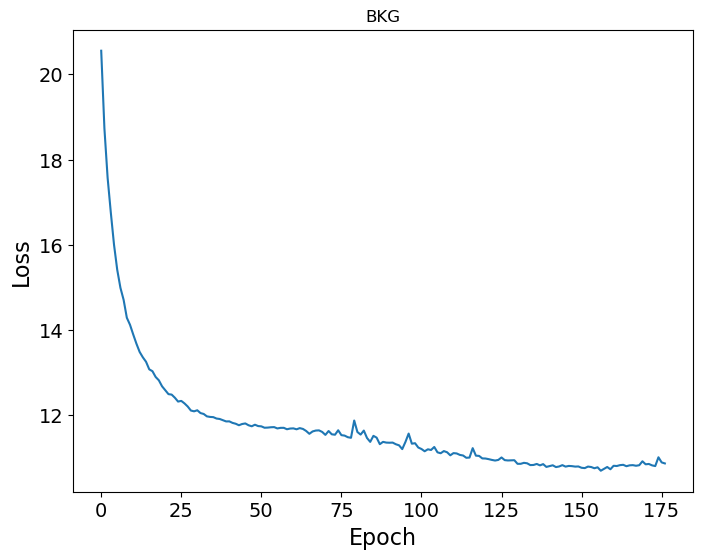

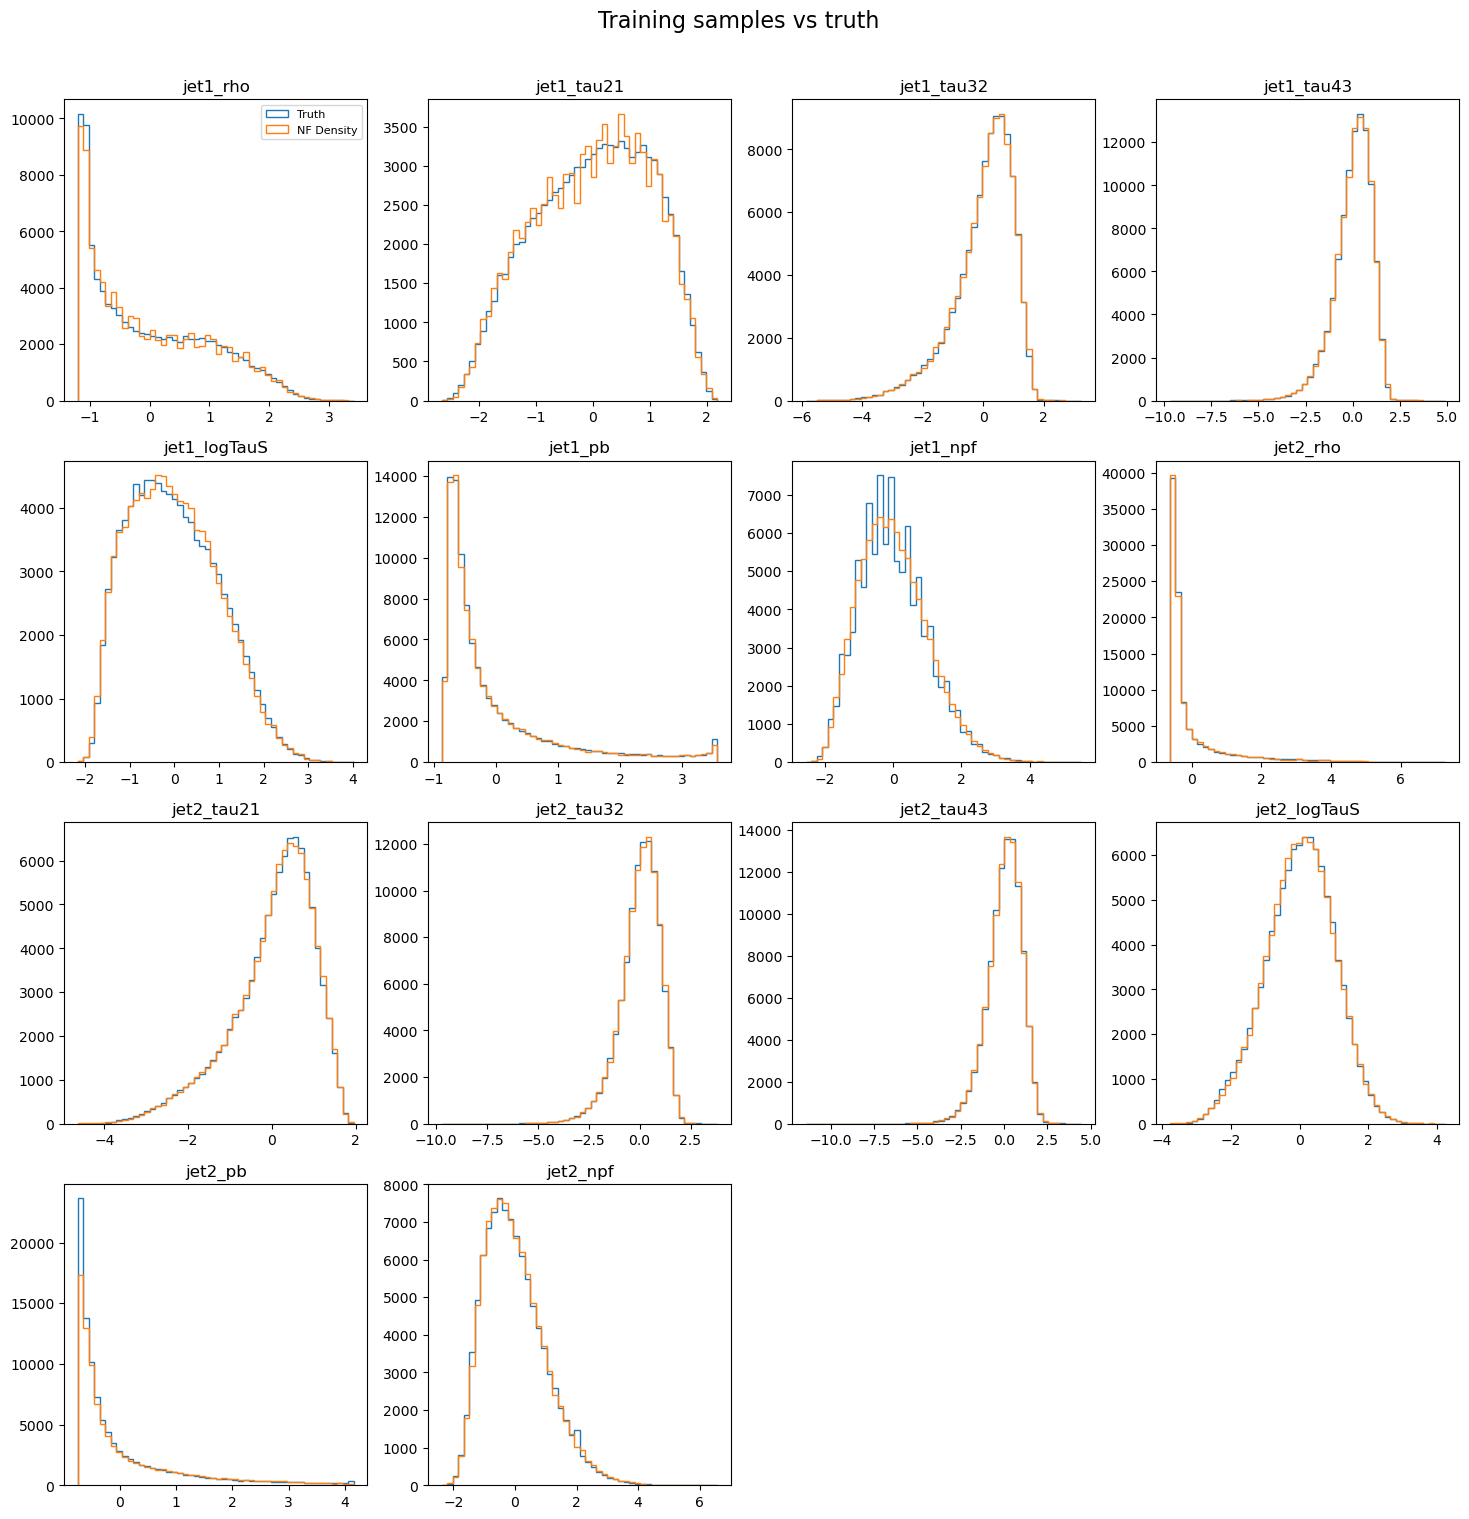

Loading test sample


 12%|█▎        | 10/80 [00:00<00:04, 16.39it/s]


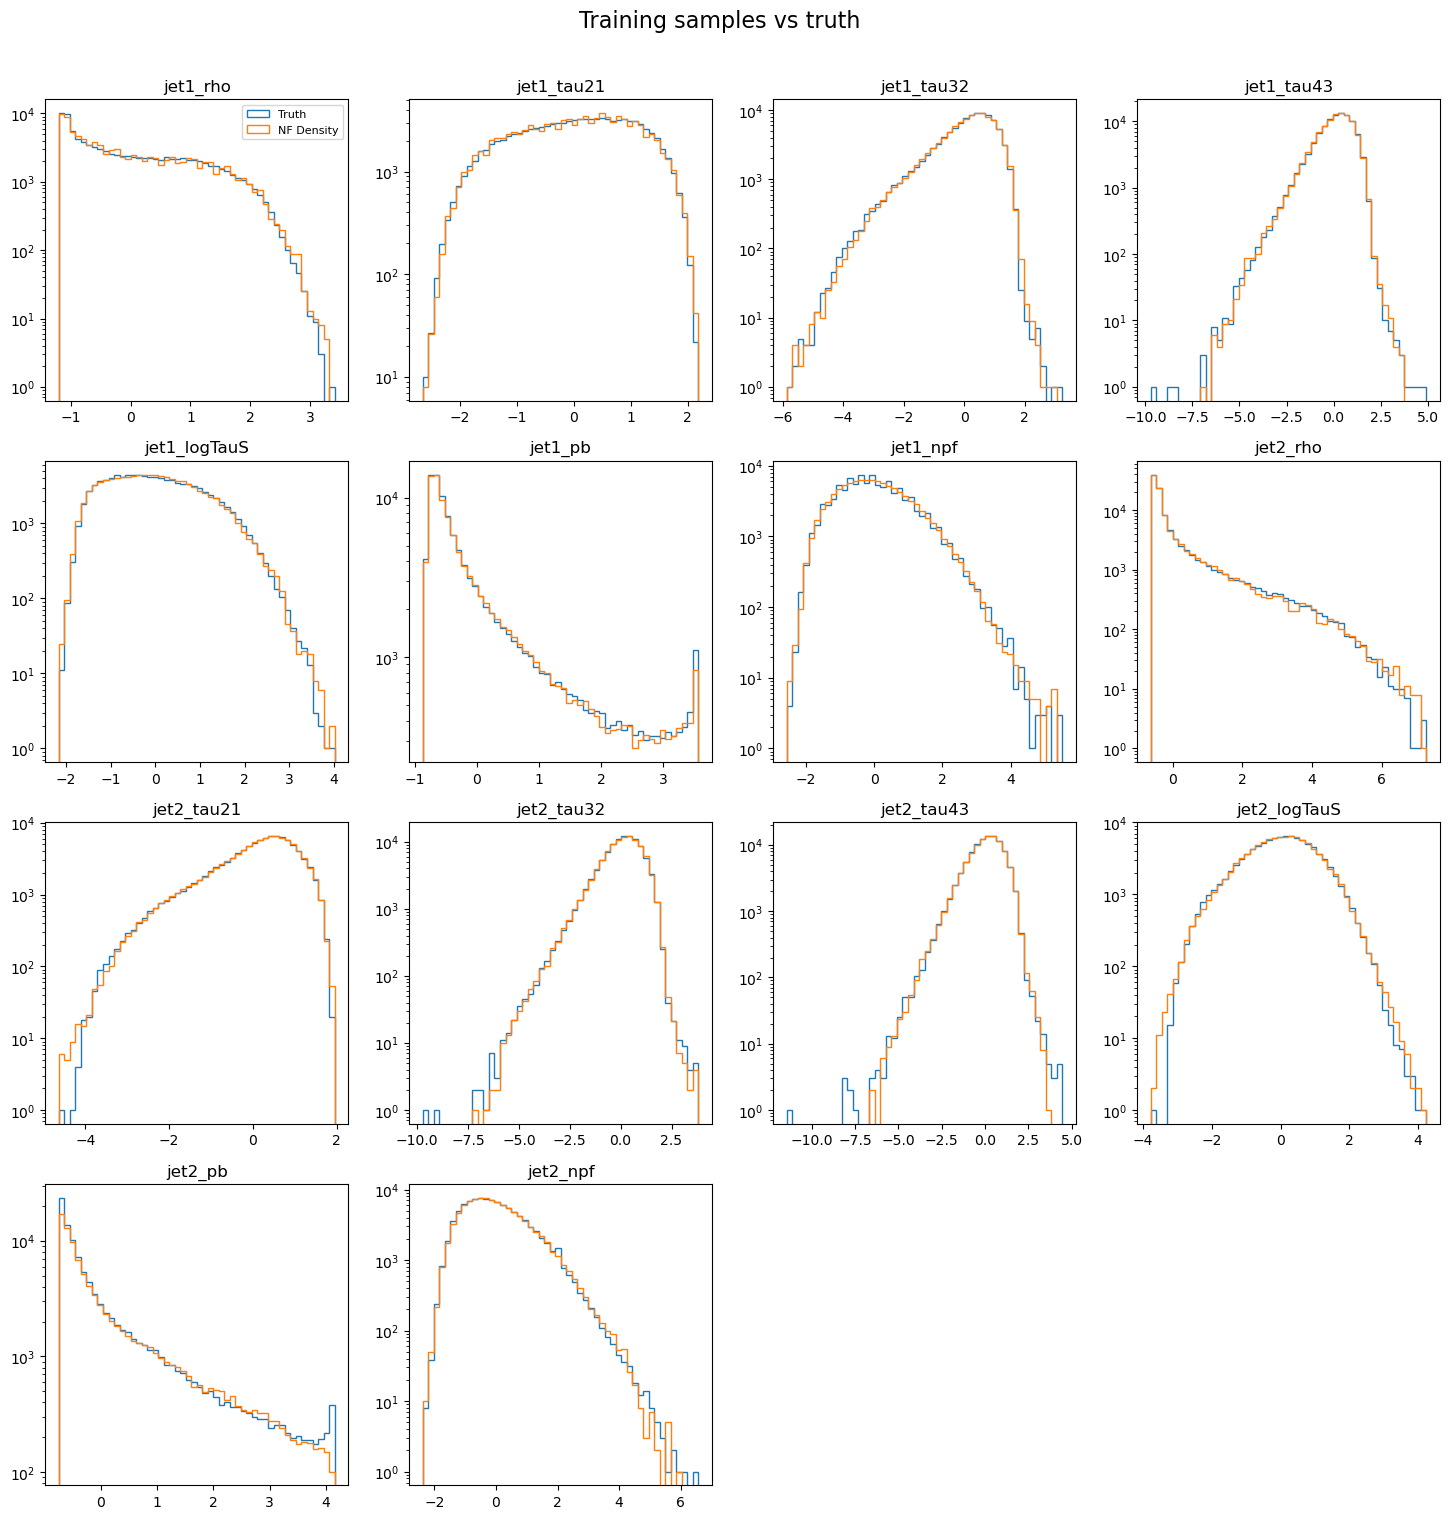

In [4]:
# Background
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":12,"hidden_features":160,
             "num_layers":6,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}

sample = "BKG"
reference = "BKG"
variables = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
nTrain = 100000
trainer = NFTrainer(sample,reference,variables,
                    nTrain=nTrain,NF_kwargs=NF_kwargs)
trainer.train(bs=10000,n_epoch=200,patience=20,learning_rate=1e-4,
              print_interval=10,T_max=50,eta_min=1e-5)
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)

Loading test sample


  1%|▏         | 1/80 [00:00<00:06, 11.50it/s]


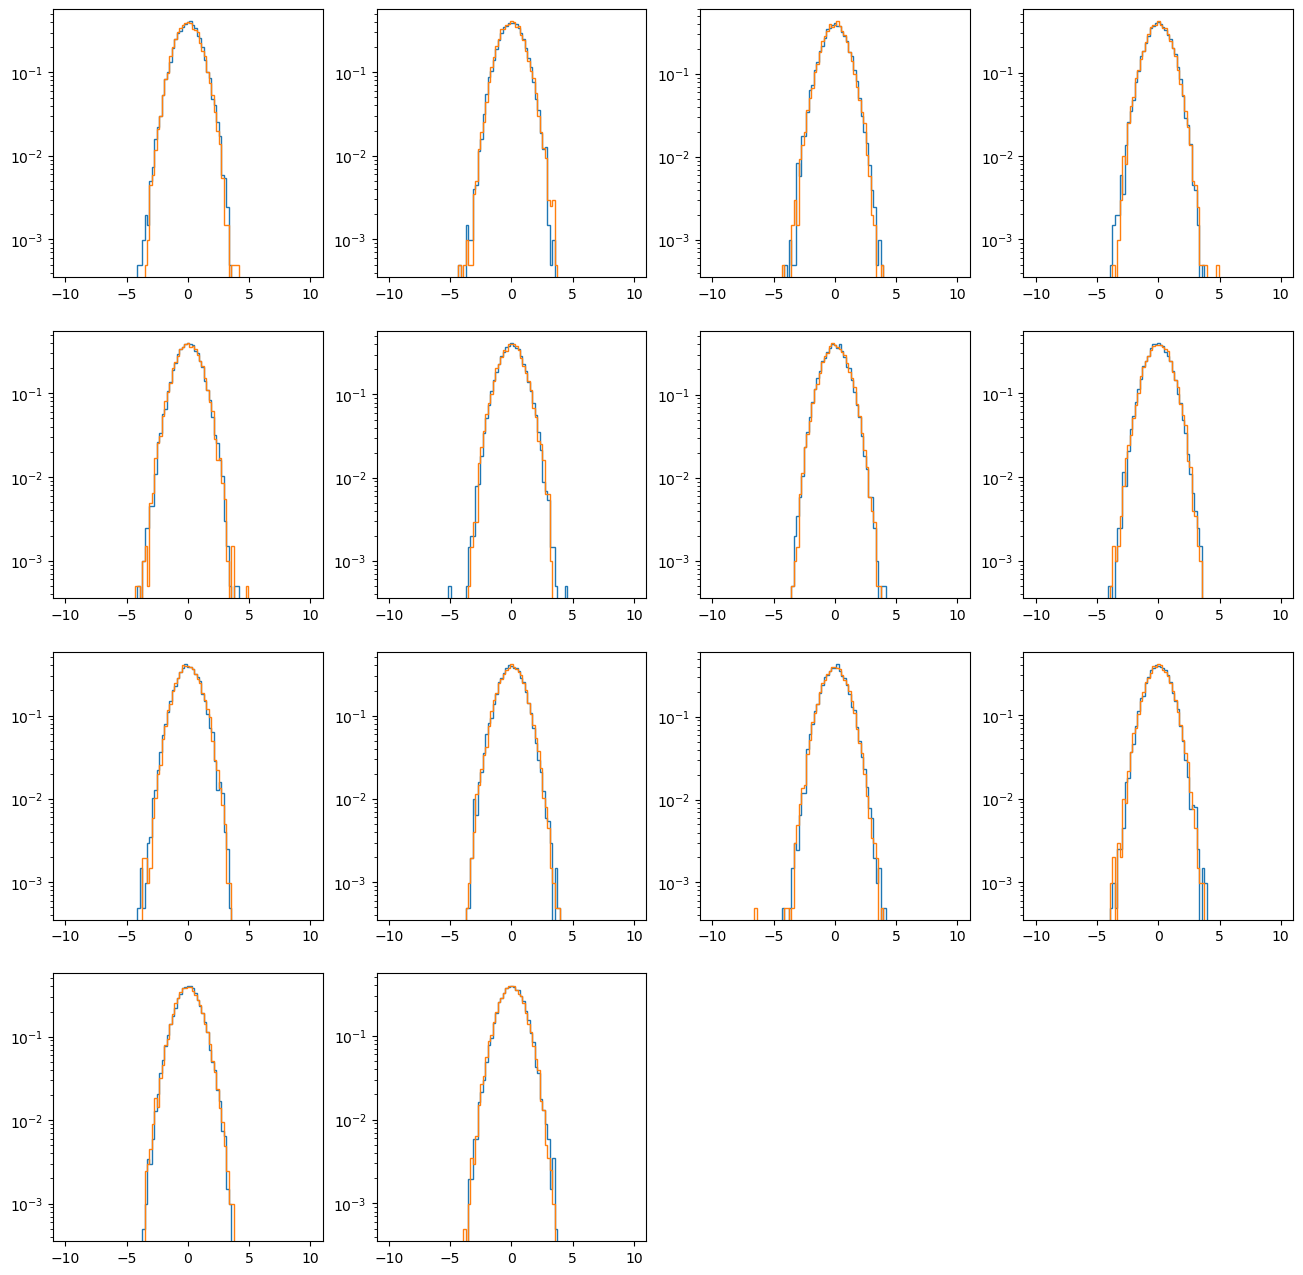

In [5]:
test = trainer.get_model().to(device)
data = trainer.loadData(10000,mode="test")
with torch.no_grad():
    samples = test.transform_to_noise(torch.tensor(data,dtype=torch.float32)).detach().cpu().numpy()
plt.figure(figsize=(16,16))
for i in range(samples.shape[1]):
    plt.subplot(4,4,i+1)
    h = plt.hist(np.random.normal(loc=0,scale=1,size=10000),density=True,histtype='step',bins=np.linspace(-10,10,100))
    h = plt.hist(samples[:,i],histtype='step',density=True,bins=np.linspace(-10,10,100))
    plt.yscale('log')
del test, data,
torch.cuda.empty_cache()

Loading train sample


100%|██████████| 1/1 [00:00<00:00, 13.55it/s]

90293 training events
Training flow BKG_mjjFlat


Iteration 10 Complete
Loss:  15.140986442565918
Iteration 20 Complete
Loss:  13.710405349731445
Iteration 30 Complete
Loss:  13.15060806274414
Iteration 40 Complete
Loss:  12.87130355834961
Iteration 50 Complete
Loss:  12.8294095993042
Iteration 60 Complete
Loss:  12.77309513092041
Iteration 70 Complete
Loss:  12.648189544677734
Iteration 80 Complete
Loss:  12.494359016418457
Iteration 90 Complete
Loss:  12.375255584716797
Iteration 100 Complete
Loss:  12.212711334228516
Iteration 110 Complete
Loss:  12.140969276428223
Iteration 120 Complete
Loss:  12.005414962768555
Iteration 130 Complete
Loss:  11.888313293457031
Iteration 140 Complete
Loss:  11.771580696105957
Iteration 150 Complete
Loss:  11.717240333557129
Iteration 160 Complete
Loss:  11.762320518493652
Iteration 170 Complete
Loss:  11.825008392333984
Iteration 180 Complete
Loss:  11.892728805541992
Loading test sample


100%|██████████| 1/1 [00:00<00:00, 29.17it/s]


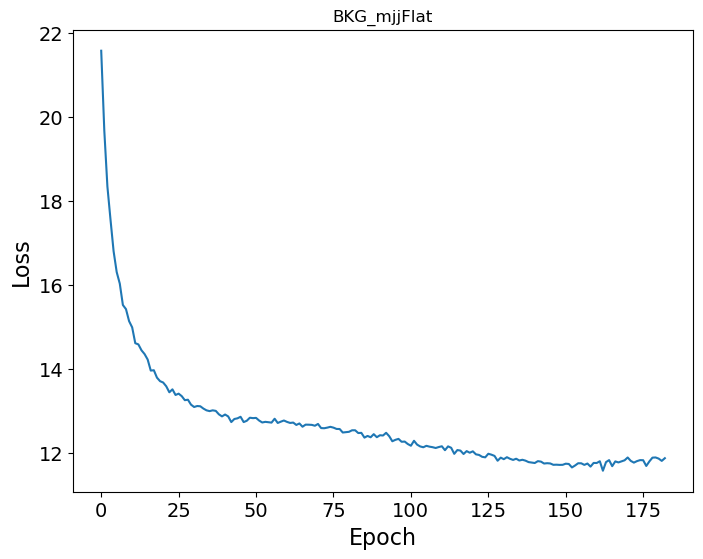

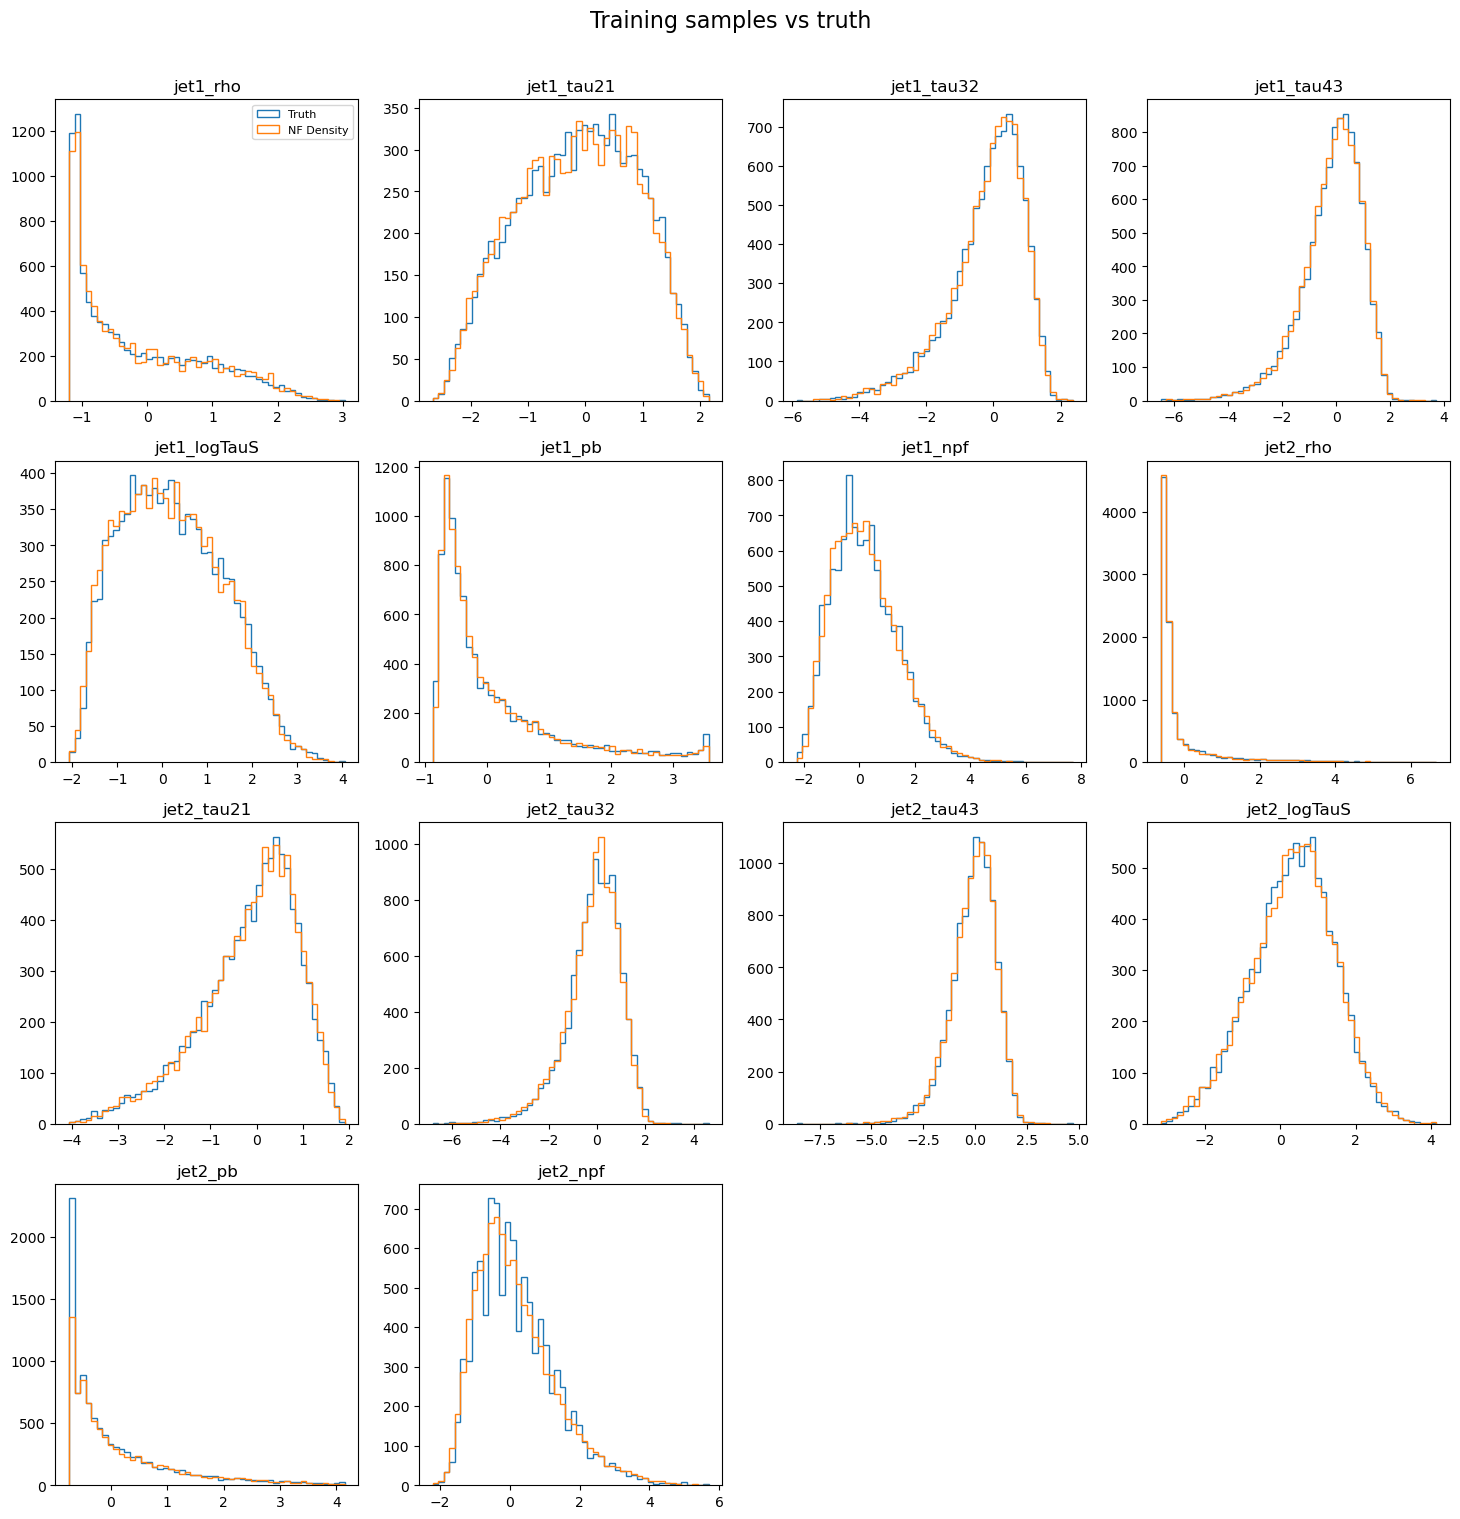

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 128.93it/s]


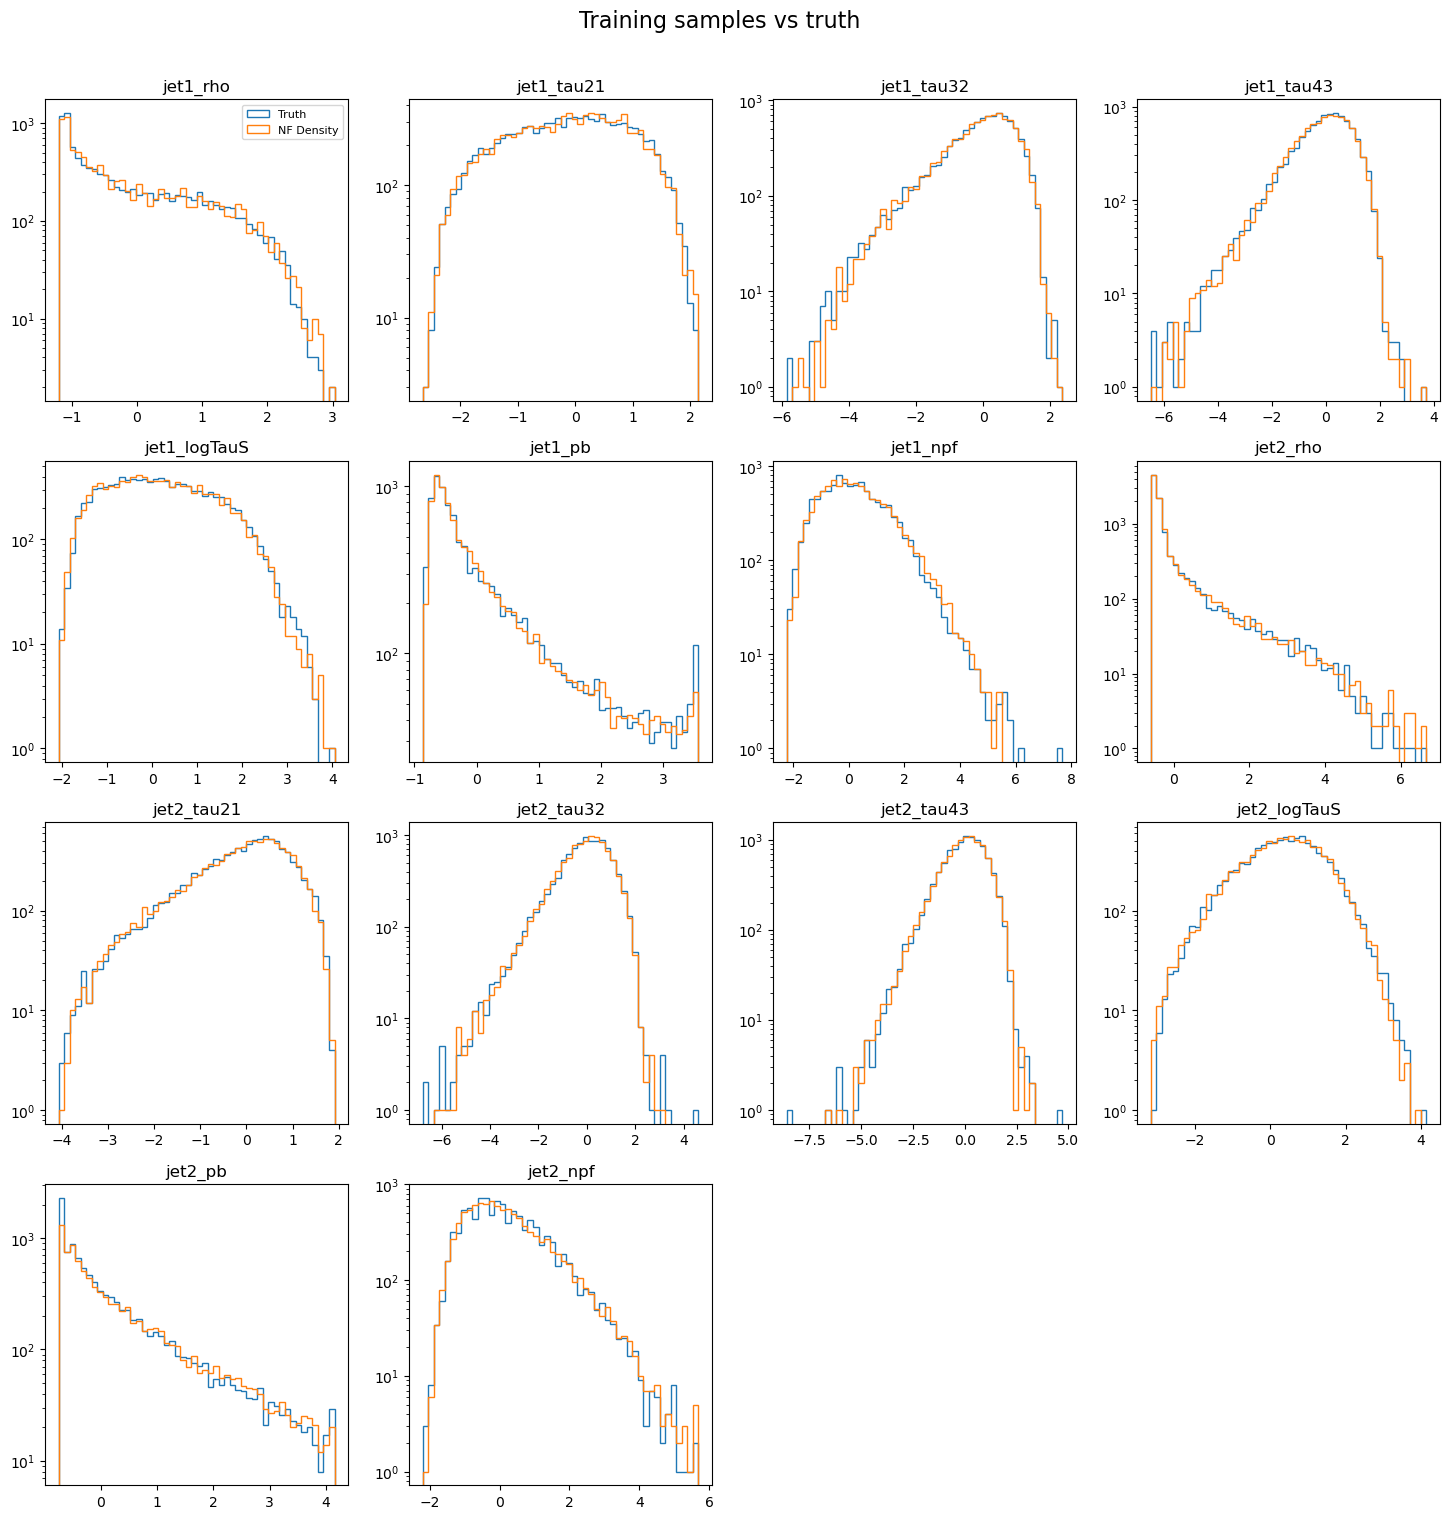

In [9]:
# Mjj-flattened background
#NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":12,"hidden_features":350,
#             "num_layers":4,"num_bins":150,"num_blocks_per_layer":8,"tails":"linear"}
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":12,"hidden_features":160,
             "num_layers":6,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}
sample = "BKG_mjjFlat"
reference = "BKG"
variables = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
nTrain = 100000
trainer = NFTrainer(sample,reference,variables,
                    nTrain=nTrain,NF_kwargs=NF_kwargs,
                   dEta_cut=1.3) 
trainer.train(bs=8000,n_epoch=200,patience=20,learning_rate=1e-4,
              print_interval=10,T_max=50,eta_min=1e-5)
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)

Loading test sample


  0%|          | 0/1 [00:00<?, ?it/s]


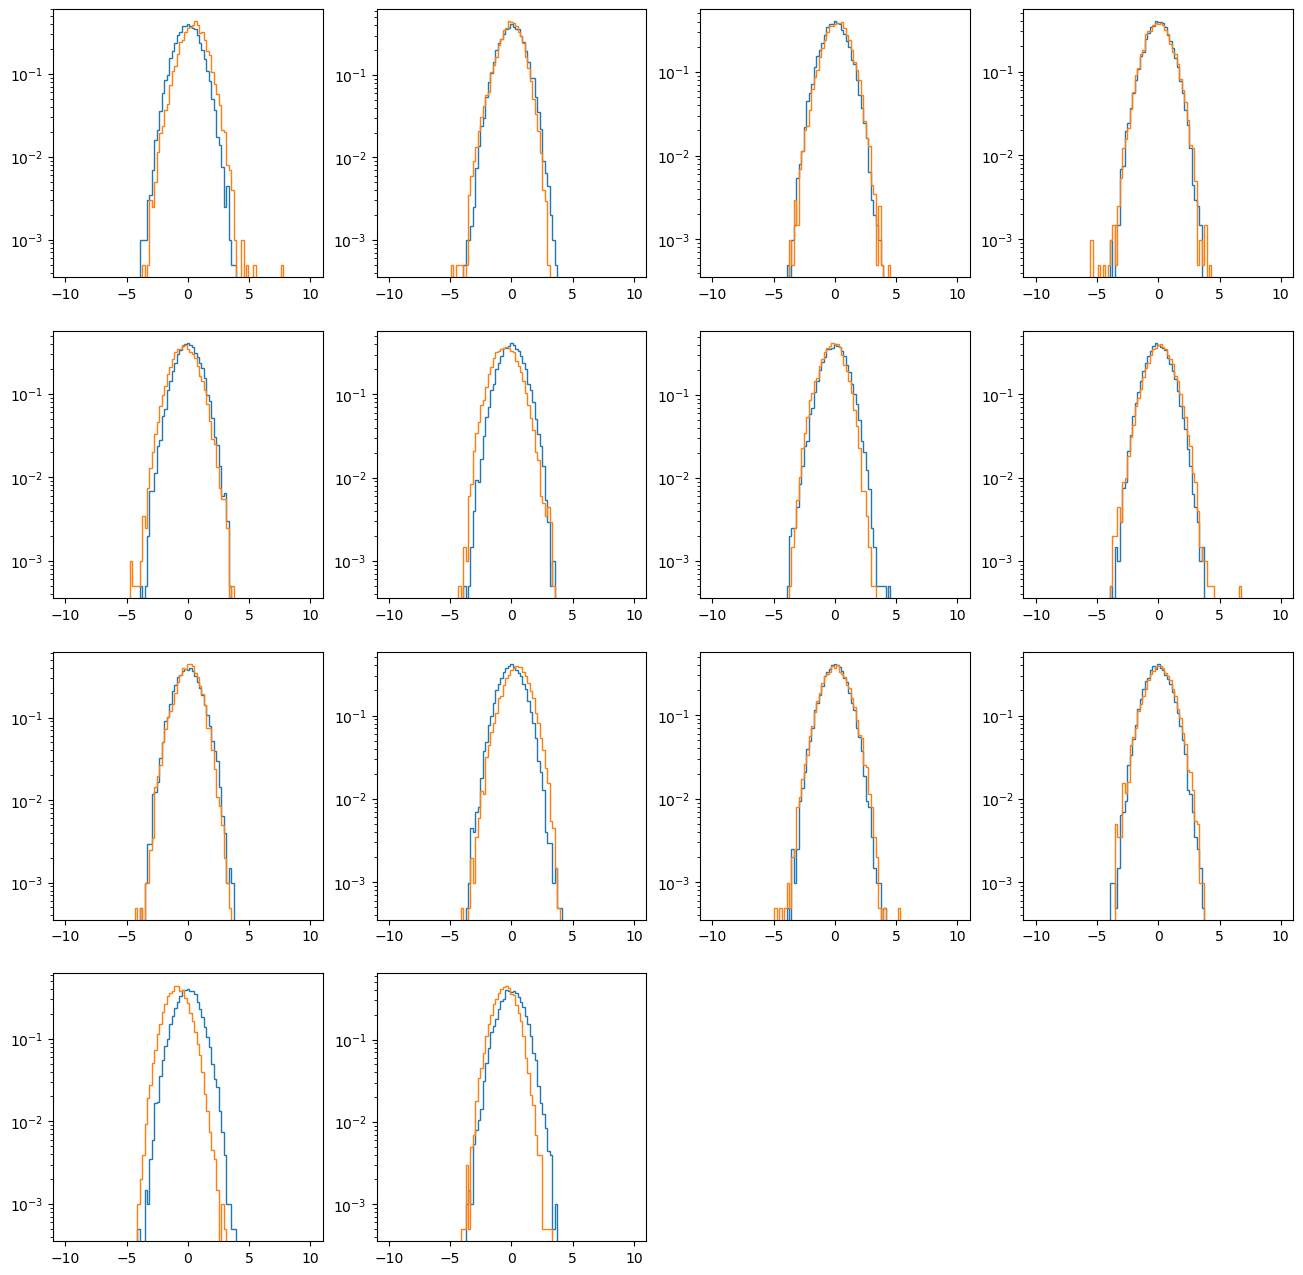

In [4]:
test = trainer.get_model().to(device)
data = trainer.loadData(10000,mode="test")
with torch.no_grad():
    samples = test.transform_to_noise(torch.tensor(data,dtype=torch.float32)).detach().cpu().numpy()
plt.figure(figsize=(16,16))
for i in range(samples.shape[1]):
    plt.subplot(4,4,i+1)
    h = plt.hist(np.random.normal(loc=0,scale=1,size=10000),density=True,histtype='step',bins=np.linspace(-10,10,100))
    h = plt.hist(samples[:,i],histtype='step',density=True,bins=np.linspace(-10,10,100))
    plt.yscale('log')
del test, data,
torch.cuda.empty_cache()

# XYY3000_Y170_Yp170

Loading train sample


100%|██████████| 1/1 [00:00<00:00,  4.29it/s]


76524 training events
Training flow XYY3000_Y170_Yp170
Iteration 10 Complete
Loss:  12.46703815460205
Iteration 20 Complete
Loss:  11.05760383605957
Iteration 30 Complete
Loss:  10.643470764160156
Iteration 40 Complete
Loss:  10.52928352355957
Iteration 50 Complete
Loss:  10.346207618713379
Iteration 60 Complete
Loss:  10.410110473632812
Iteration 70 Complete
Loss:  10.330147743225098
Iteration 80 Complete
Loss:  10.230210304260254
Iteration 90 Complete
Loss:  10.1124267578125
Iteration 100 Complete
Loss:  10.058795928955078
Iteration 110 Complete
Loss:  9.910524368286133
Iteration 120 Complete
Loss:  9.87785530090332
Iteration 130 Complete
Loss:  9.781001091003418
Iteration 140 Complete
Loss:  9.745080947875977
Iteration 150 Complete
Loss:  9.776796340942383
Iteration 160 Complete
Loss:  9.769962310791016
Iteration 170 Complete
Loss:  9.725211143493652
Iteration 180 Complete
Loss:  9.77296257019043
Iteration 190 Complete
Loss:  9.713495254516602
Loading test sample


100%|██████████| 1/1 [00:00<00:00, 40.66it/s]


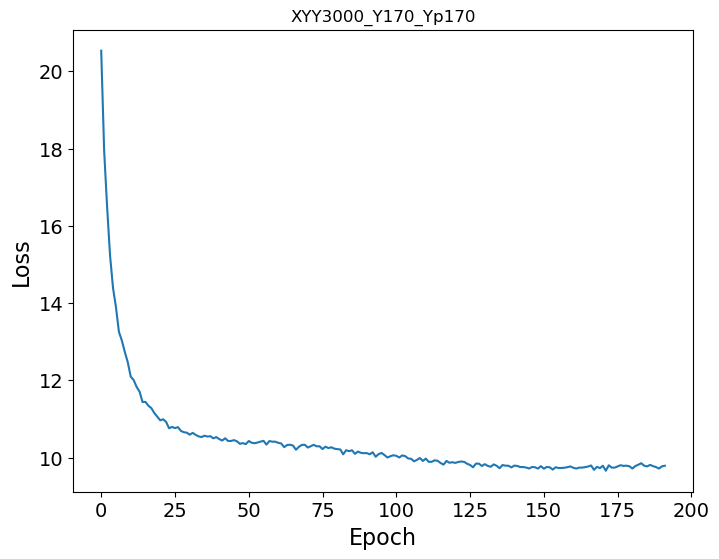

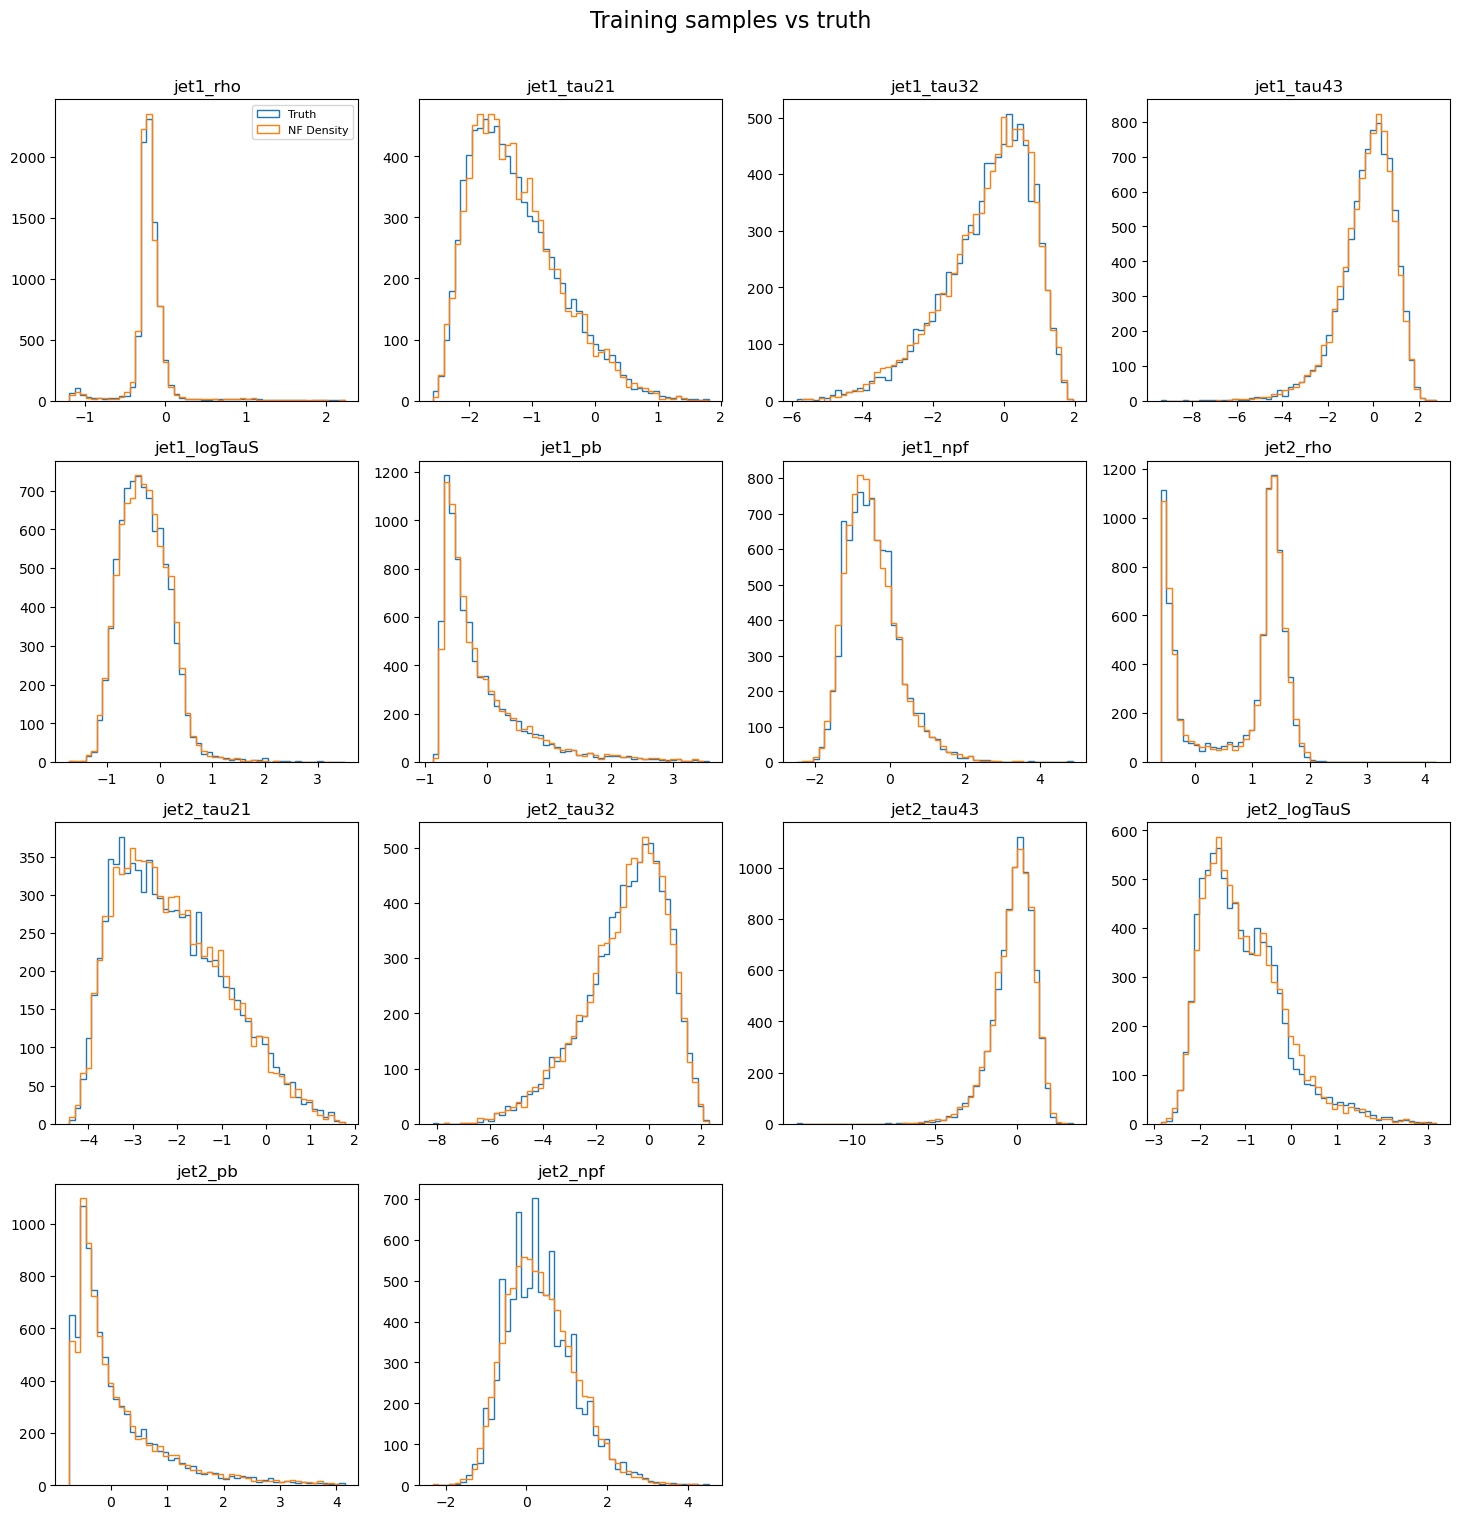

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 45.37it/s]


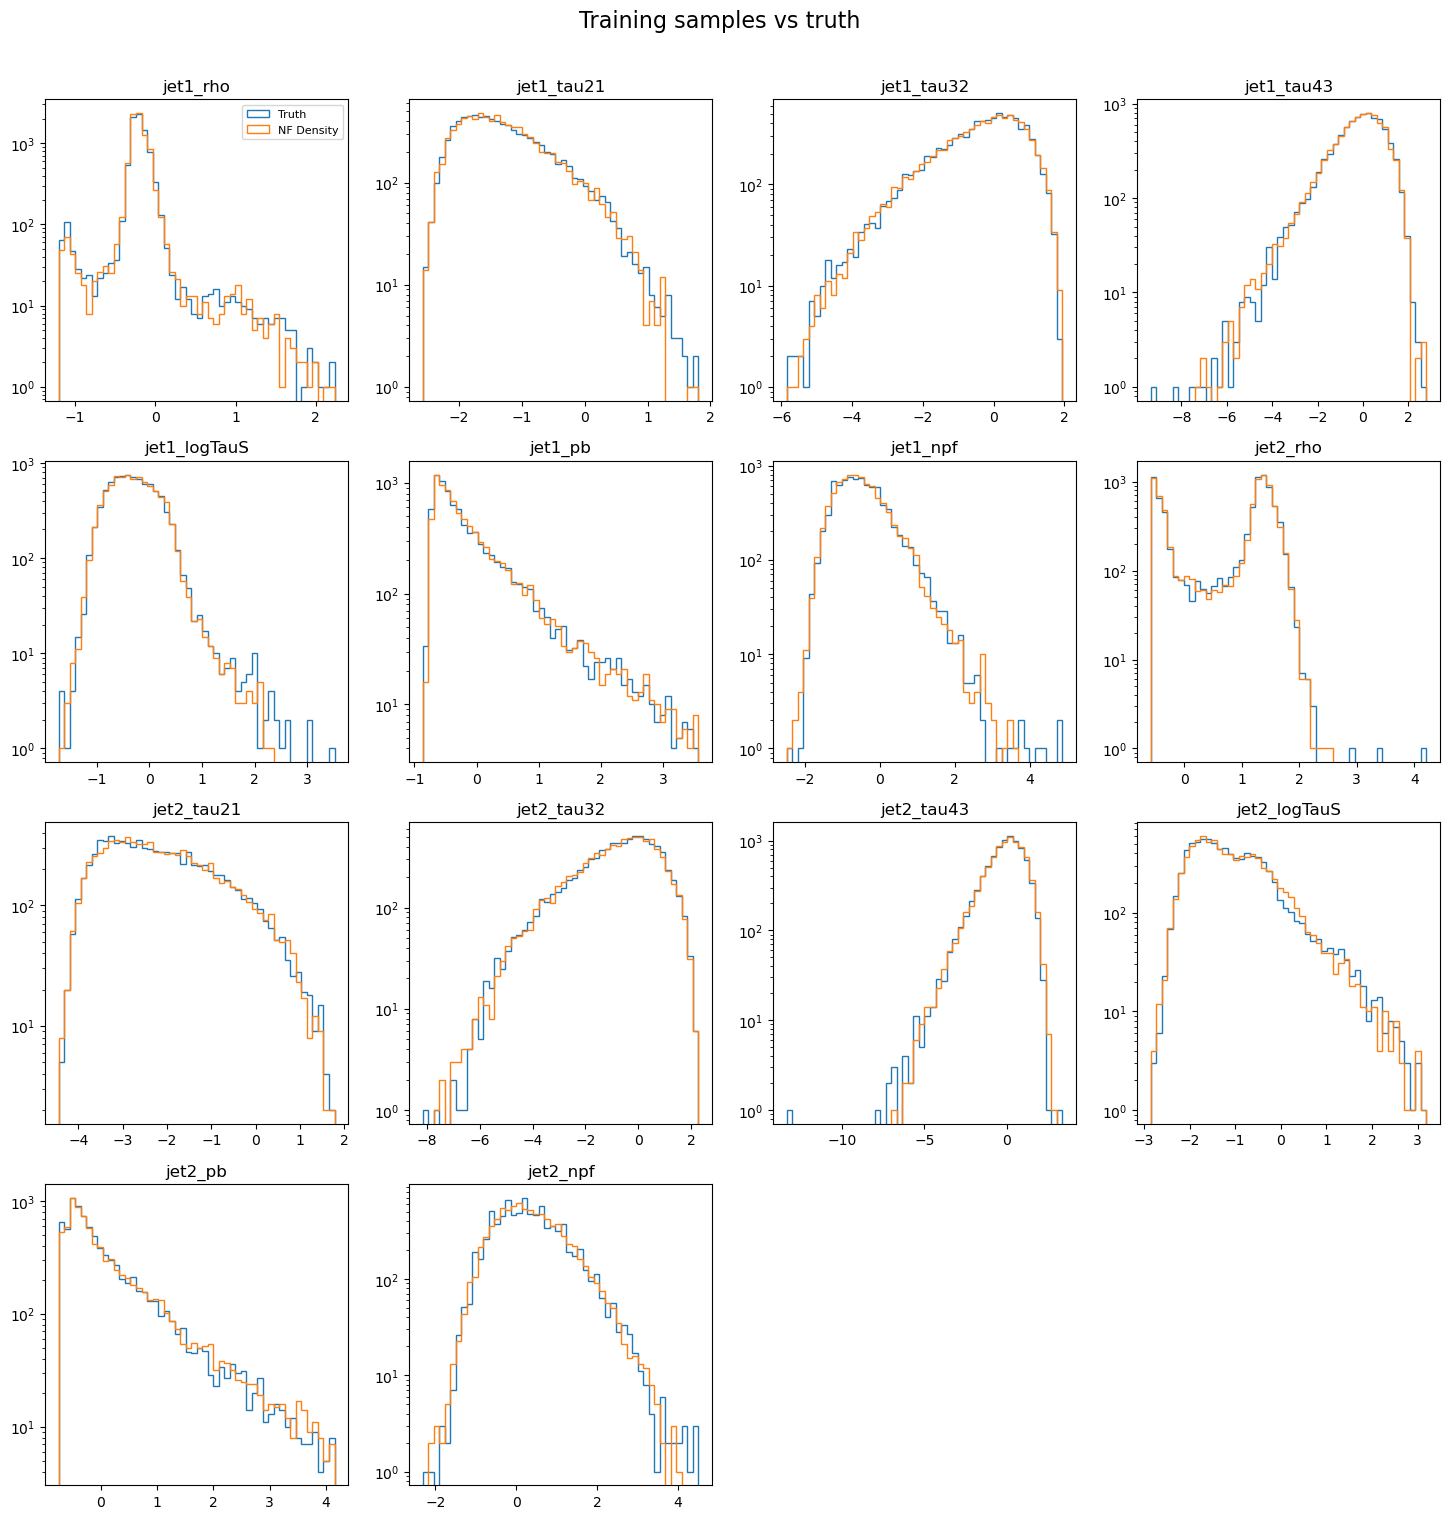

In [6]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":10,"hidden_features":160,"num_layers":4,
             "num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}
sample = "XYY3000_Y170_Yp170"
reference = "BKG"
variables = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
nTrain = 1000000
trainer = NFTrainer(sample,reference,variables,nTrain=nTrain,NF_kwargs=NF_kwargs)
trainer.train(bs=5000,n_epoch=200,patience=20,learning_rate=1e-4,T_max=50,eta_min=1e-5,print_interval=10)
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 45.58it/s]


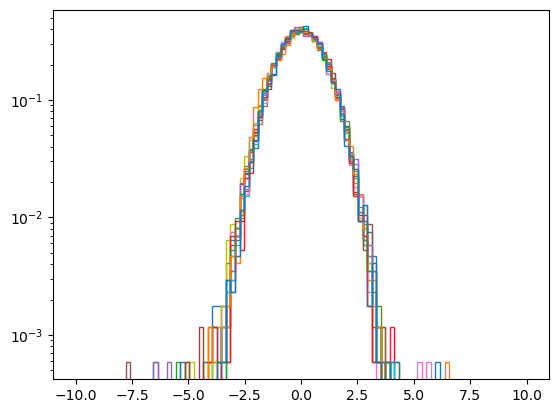

In [7]:
test = trainer.get_model().to(device)
data = trainer.loadData(10000,mode='test')
with torch.no_grad():
    samples = test.transform_to_noise(torch.tensor(data,dtype=torch.float32)).detach().cpu().numpy()
h = plt.hist(samples,histtype='step',density=True,bins=np.linspace(-10,10,100))
del test, data, samples
torch.cuda.empty_cache()
plt.yscale('log')

# Wp3000_B400_T170

Loading train sample


100%|██████████| 1/1 [00:00<00:00,  3.60it/s]


51541 training events
Training flow Wp3000_B400_T170
Iteration 10 Complete
Loss:  18.358245849609375
Iteration 20 Complete
Loss:  17.141664505004883
Iteration 30 Complete
Loss:  16.560367584228516
Iteration 40 Complete
Loss:  16.34707260131836
Iteration 50 Complete
Loss:  16.279727935791016
Iteration 60 Complete
Loss:  16.201135635375977
Iteration 70 Complete
Loss:  16.0714111328125
Iteration 80 Complete
Loss:  15.902352333068848
Iteration 90 Complete
Loss:  15.729151725769043
Iteration 100 Complete
Loss:  15.580223083496094
Iteration 110 Complete
Loss:  15.430564880371094
Iteration 120 Complete
Loss:  15.34429931640625
Iteration 130 Complete
Loss:  15.256471633911133
Iteration 140 Complete
Loss:  15.258148193359375
Iteration 150 Complete
Loss:  15.224035263061523
Iteration 160 Complete
Loss:  15.194316864013672
Iteration 170 Complete
Loss:  15.2141695022583
Iteration 180 Complete
Loss:  15.174809455871582
Iteration 190 Complete
Loss:  15.195219993591309
Iteration 200 Complete
Loss:  1

100%|██████████| 1/1 [00:00<00:00, 42.61it/s]


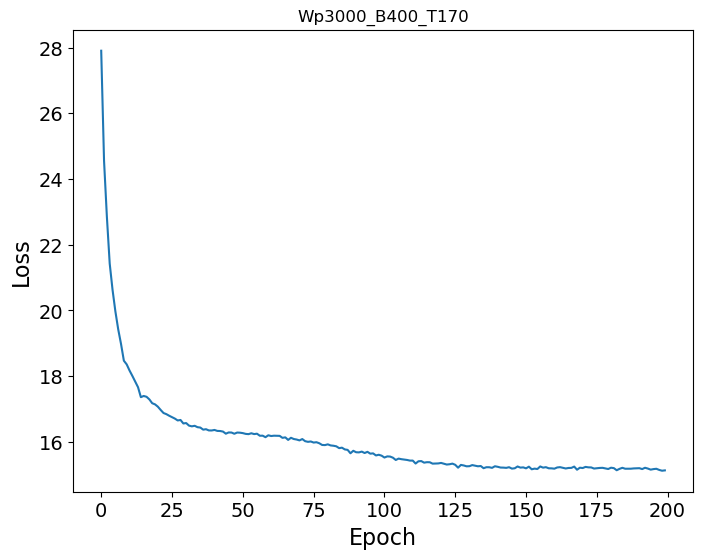

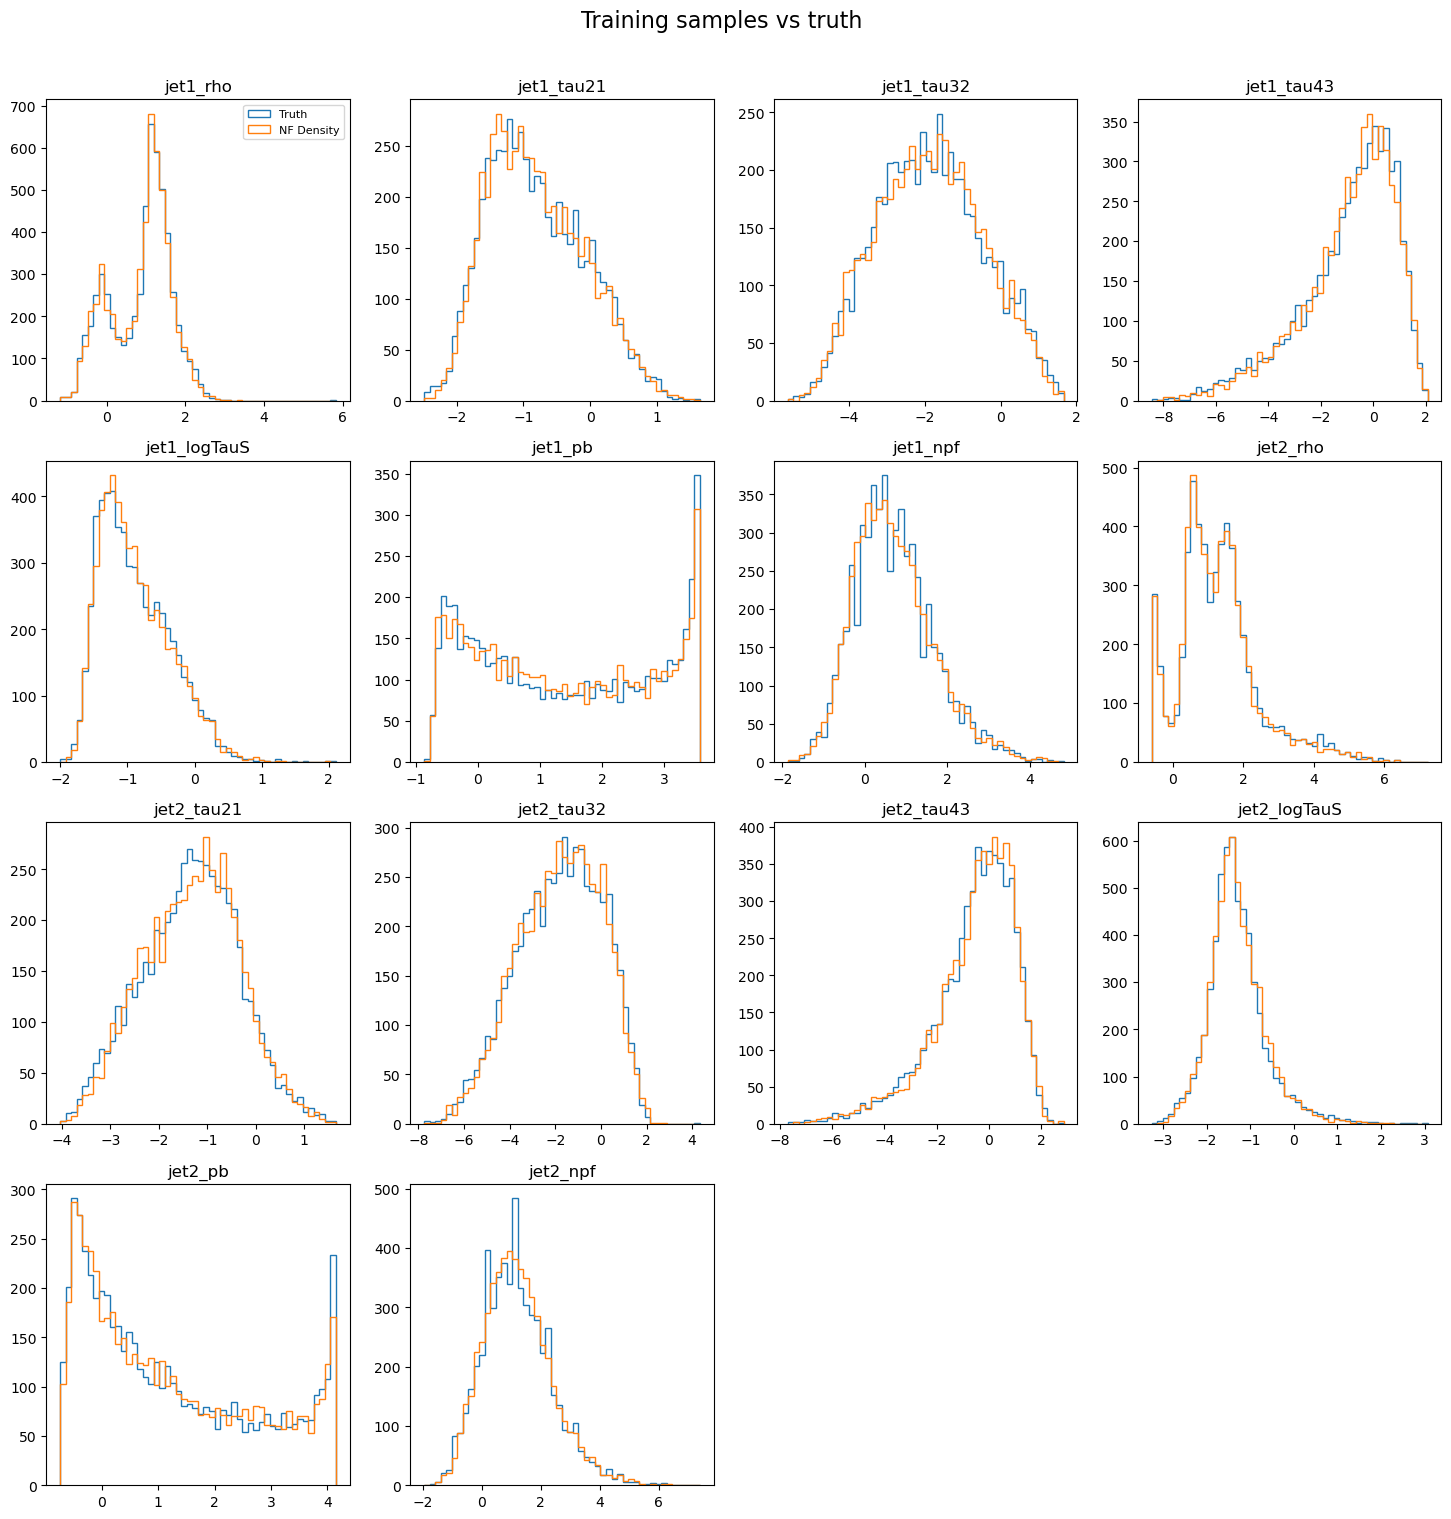

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 50.93it/s]


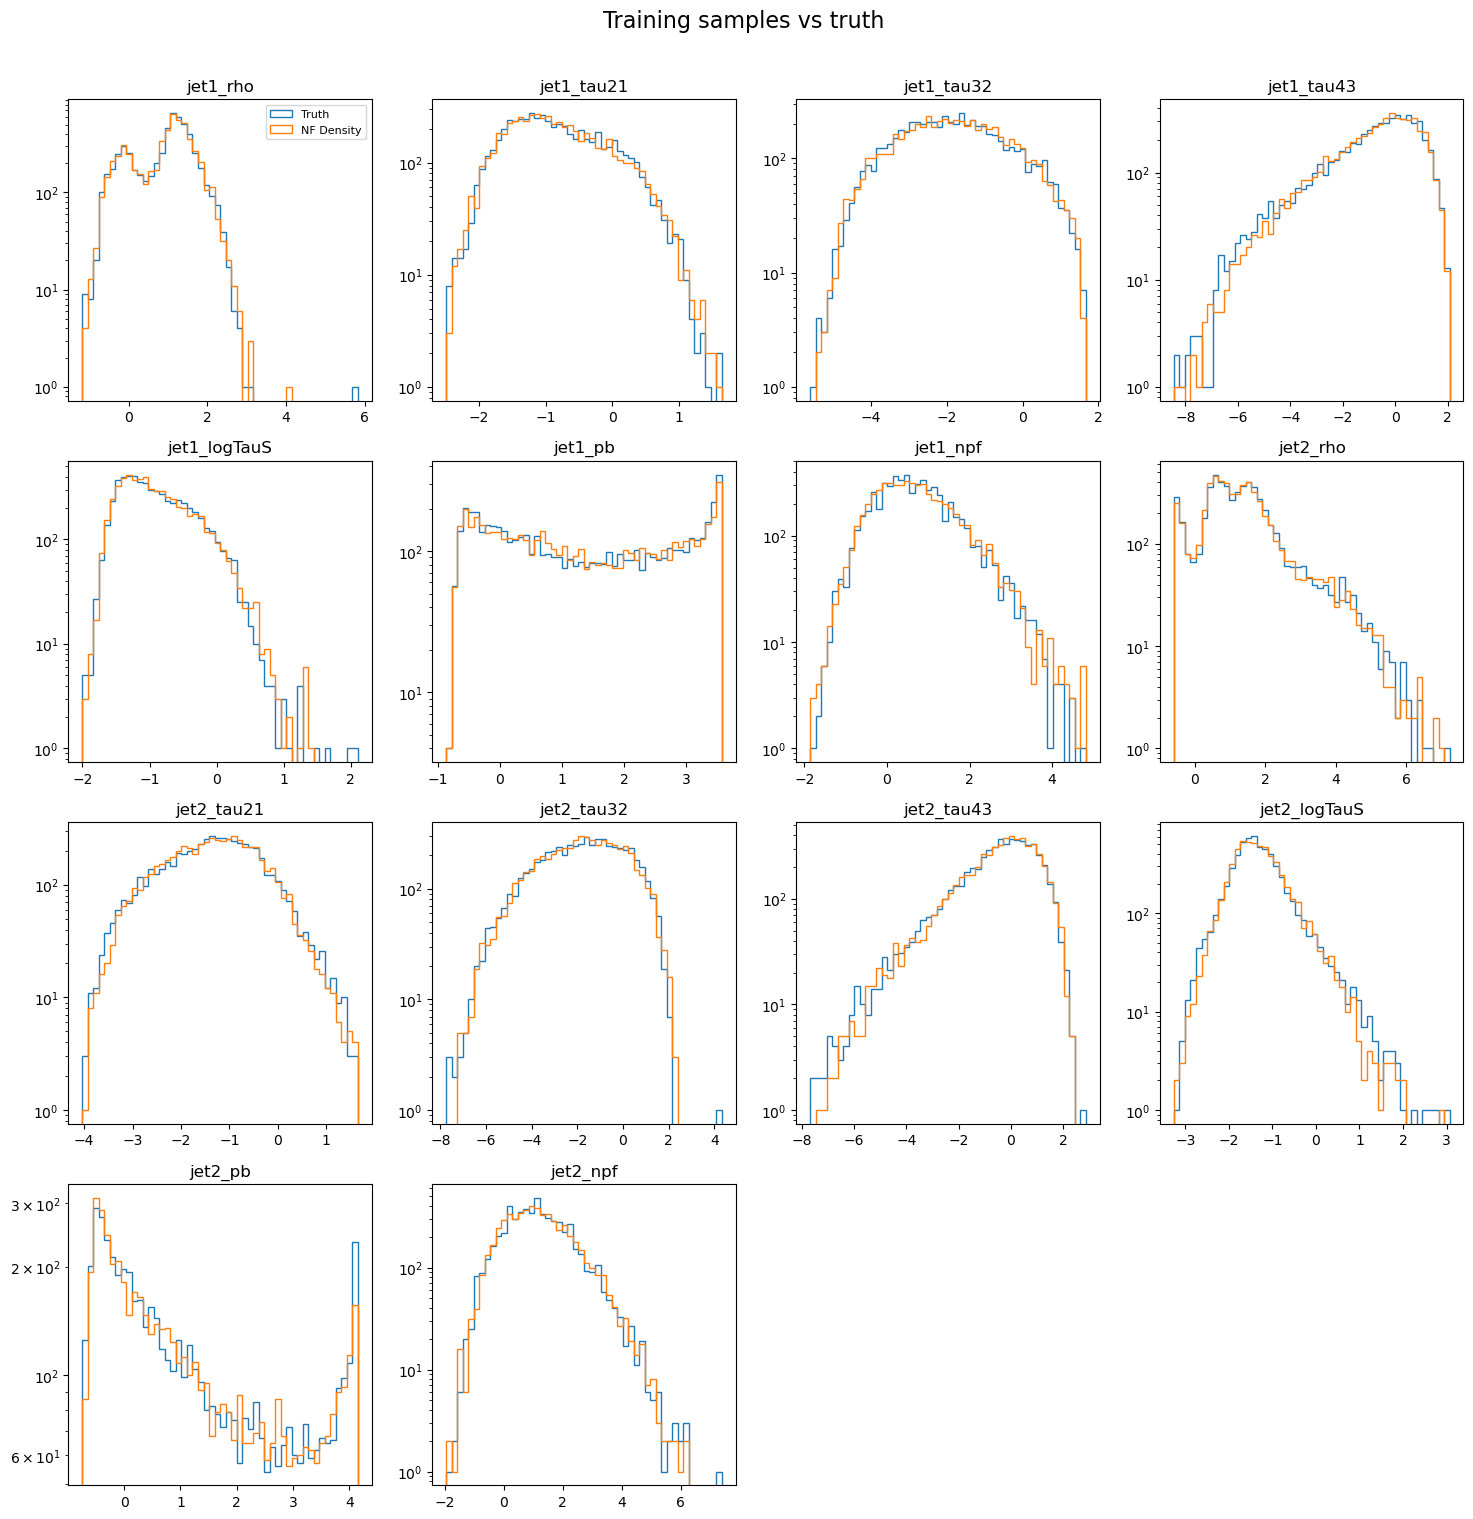

In [8]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":10,"hidden_features":160,"num_layers":4,
             "num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}
sample = "Wp3000_B400_T170"
reference = "BKG"
variables = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
nTrain = 1000000
trainer = NFTrainer(sample,reference,variables,nTrain=nTrain,NF_kwargs=NF_kwargs)
trainer.train(bs=5000,n_epoch=200,patience=20,learning_rate=1e-4,T_max=50,eta_min=1e-5,print_interval=10)
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 51.36it/s]


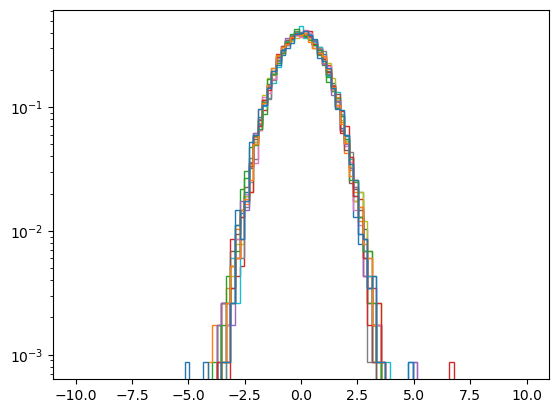

In [9]:
test = trainer.get_model().to(device)
data = trainer.loadData(10000,mode='test')
with torch.no_grad():
    samples = test.transform_to_noise(torch.tensor(data,dtype=torch.float32)).detach().cpu().numpy()
h = plt.hist(samples,histtype='step',density=True,bins=np.linspace(-10,10,100))
del test, data, samples
torch.cuda.empty_cache()
plt.yscale('log')

# Qstar2000_W400

Loading train sample


100%|██████████| 1/1 [00:00<00:00, 56.16it/s]

50965 training events
Training flow Qstar2000_W400


Iteration 10 Complete
Loss:  15.478071212768555
Iteration 20 Complete
Loss:  13.521577835083008
Iteration 30 Complete
Loss:  12.400800704956055
Iteration 40 Complete
Loss:  12.195780754089355
Iteration 50 Complete
Loss:  12.026371955871582
Iteration 60 Complete
Loss:  11.723832130432129
Iteration 70 Complete
Loss:  11.784173011779785
Iteration 80 Complete
Loss:  11.779742240905762
Iteration 90 Complete
Loss:  11.675131797790527
Iteration 100 Complete
Loss:  11.481674194335938
Iteration 110 Complete
Loss:  11.108220100402832
Iteration 120 Complete
Loss:  11.08554458618164
Iteration 130 Complete
Loss:  10.746138572692871
Iteration 140 Complete
Loss:  10.421418190002441
Iteration 150 Complete
Loss:  10.58785629272461
Iteration 160 Complete
Loss:  10.487560272216797
Loading test sample


100%|██████████| 1/1 [00:00<00:00, 52.26it/s]


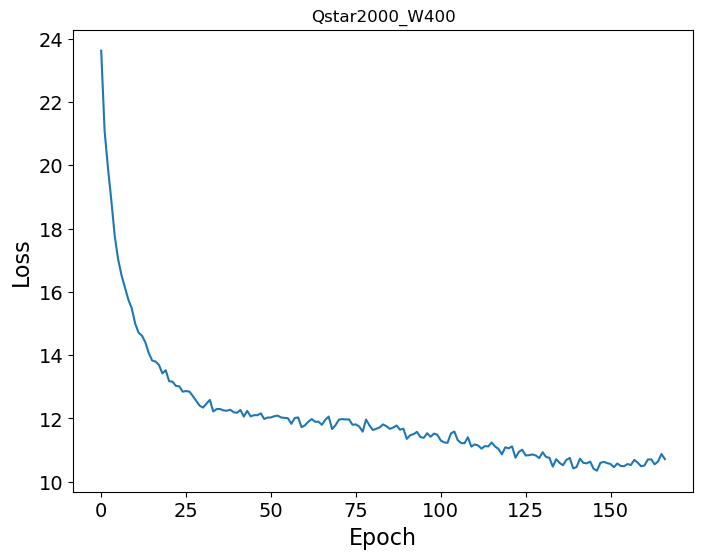

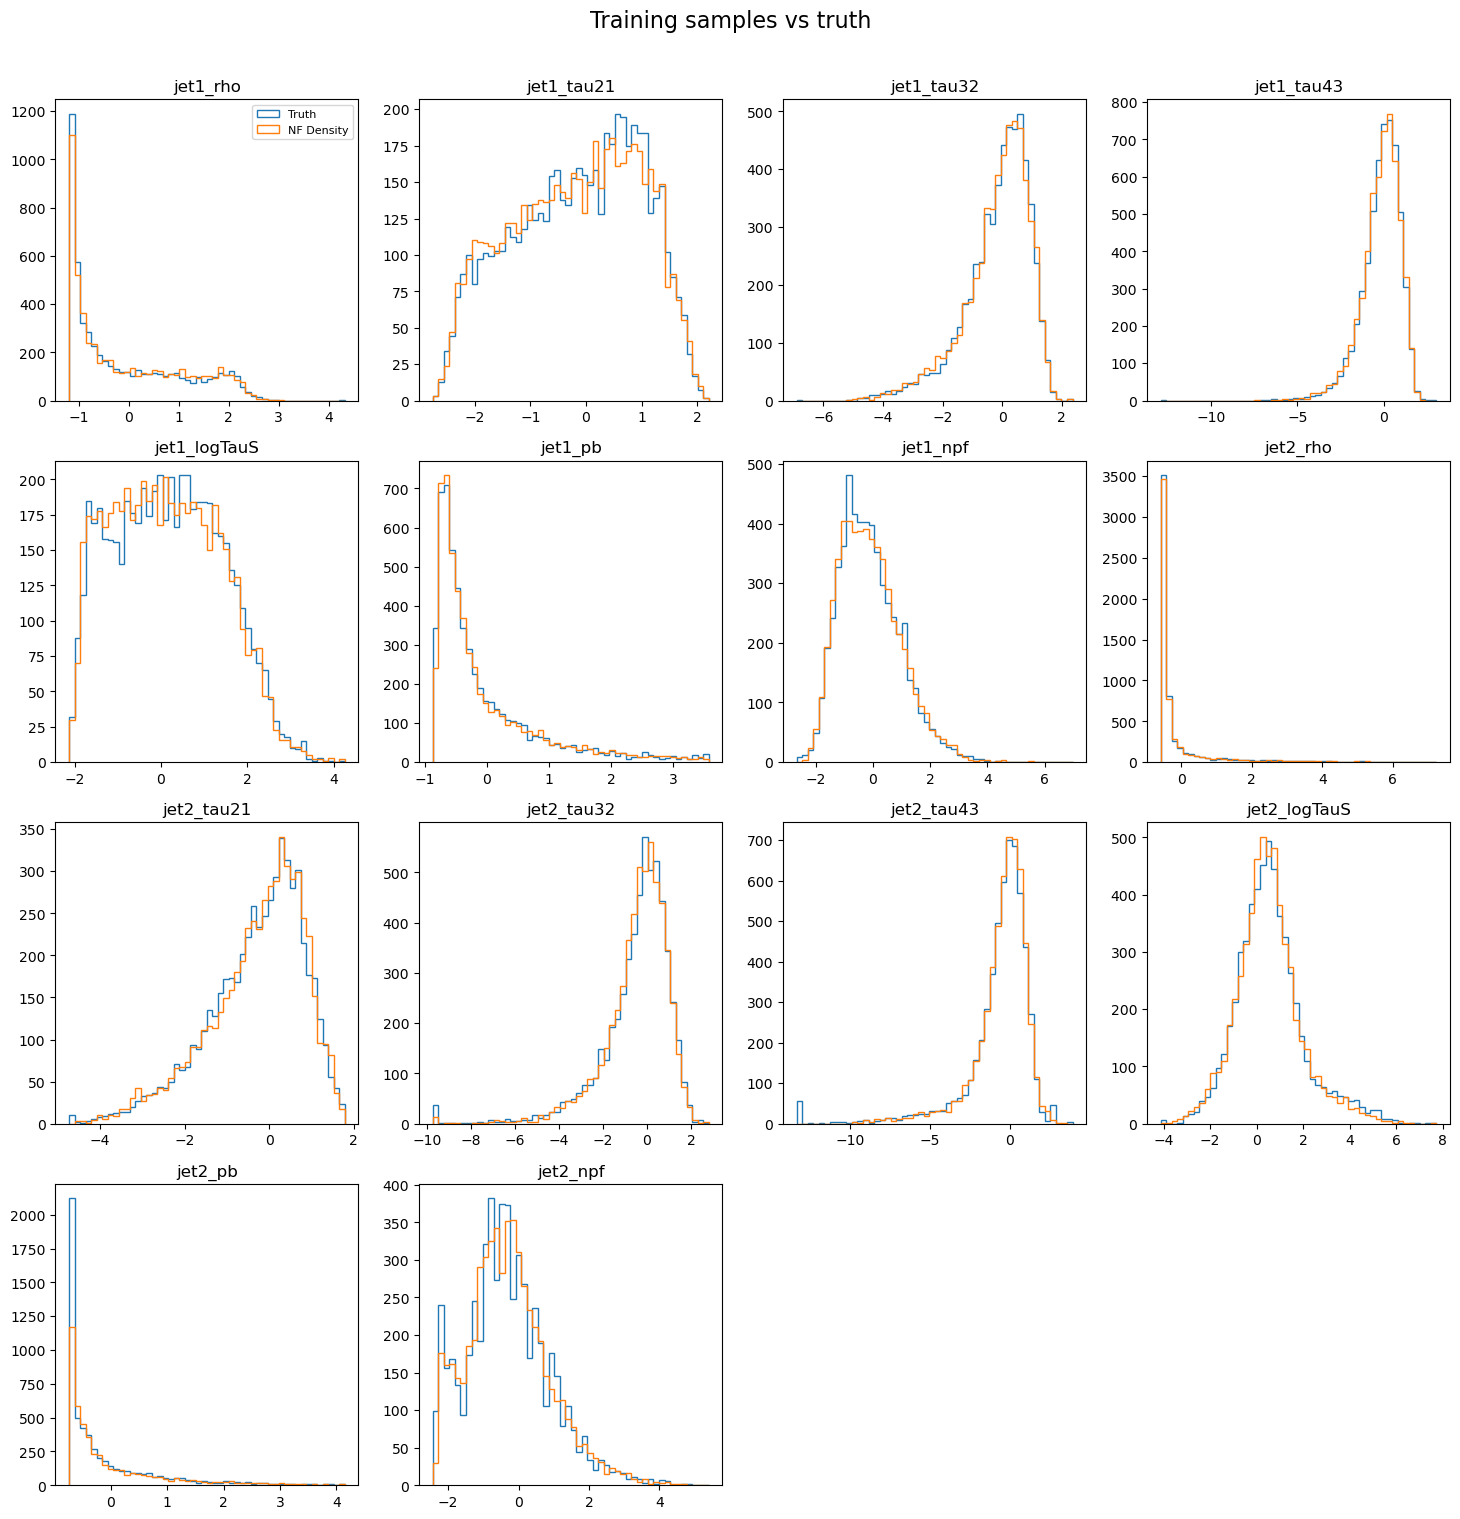

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 49.90it/s]


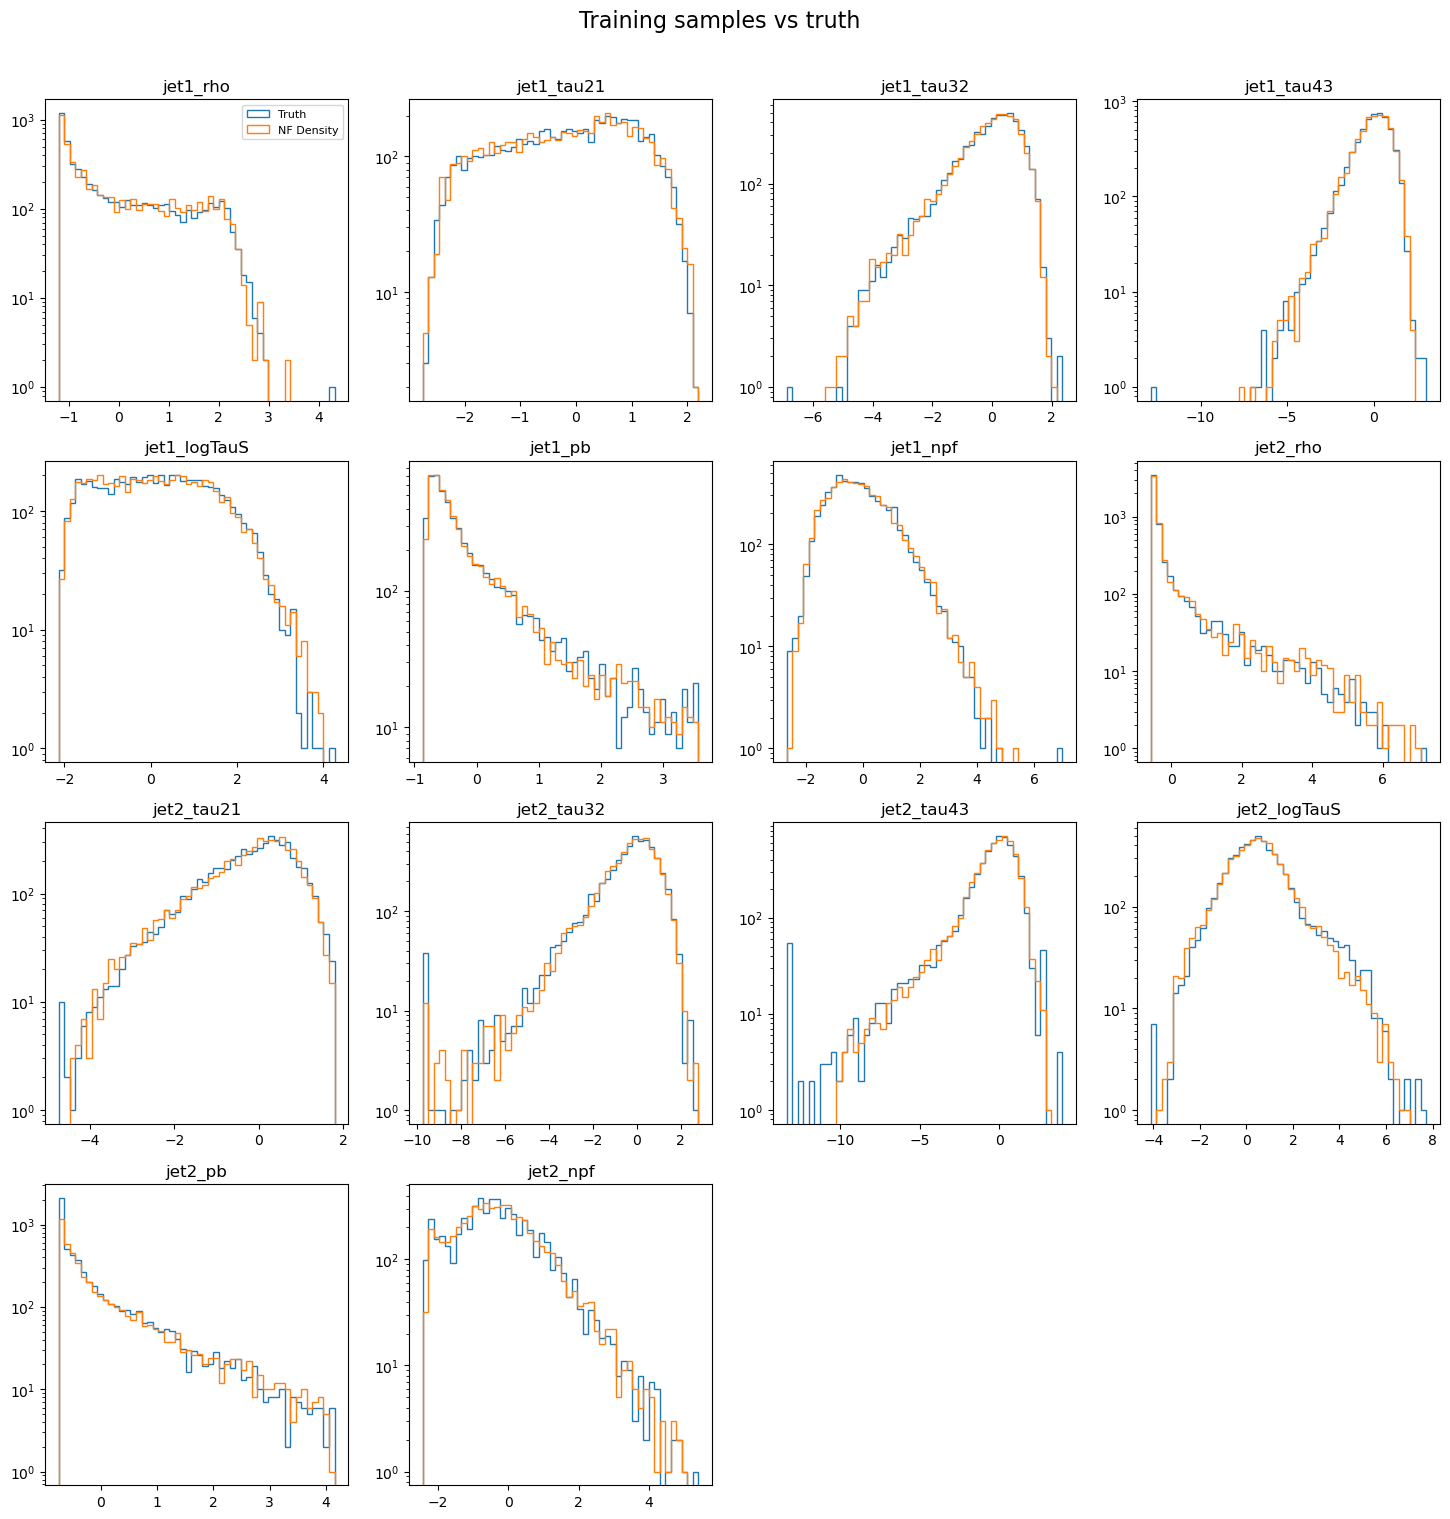

In [12]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":10,"hidden_features":160,"num_layers":4,
             "num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}
sample = "Qstar2000_W400"
reference = "BKG"
variables = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
nTrain = 1000000
trainer = NFTrainer(sample,reference,variables,nTrain=nTrain,NF_kwargs=NF_kwargs)
trainer.train(bs=3000,n_epoch=200,patience=20,learning_rate=1e-4,T_max=50,eta_min=1e-5,print_interval=10)
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 52.97it/s]


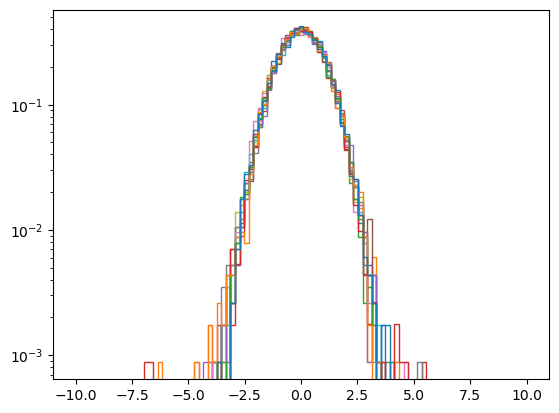

In [13]:
test = trainer.get_model().to(device)
data = trainer.loadData(10000,mode='test')
with torch.no_grad():
    samples = test.transform_to_noise(torch.tensor(data,dtype=torch.float32)).detach().cpu().numpy()
h = plt.hist(samples,histtype='step',density=True,bins=np.linspace(-10,10,100))
del test, data, samples
torch.cuda.empty_cache()
plt.yscale('log')

# Wkk3000_R400

Loading train sample


100%|██████████| 1/1 [00:00<00:00,  3.43it/s]


41015 training events
Training flow Wkk3000_R400
Iteration 10 Complete
Loss:  19.17168426513672
Iteration 20 Complete
Loss:  16.75248146057129
Iteration 30 Complete
Loss:  15.362783432006836
Iteration 40 Complete
Loss:  14.738849639892578
Iteration 50 Complete
Loss:  14.653117179870605
Iteration 60 Complete
Loss:  14.161942481994629
Iteration 70 Complete
Loss:  14.45382308959961
Iteration 80 Complete
Loss:  14.41500473022461
Iteration 90 Complete
Loss:  14.006988525390625
Iteration 100 Complete
Loss:  13.58057689666748
Iteration 110 Complete
Loss:  13.375231742858887
Iteration 120 Complete
Loss:  13.090208053588867
Iteration 130 Complete
Loss:  12.65024185180664
Iteration 140 Complete
Loss:  12.642146110534668
Iteration 150 Complete
Loss:  12.535563468933105
Iteration 160 Complete
Loss:  12.288067817687988
Loading test sample


100%|██████████| 1/1 [00:00<00:00,  6.97it/s]


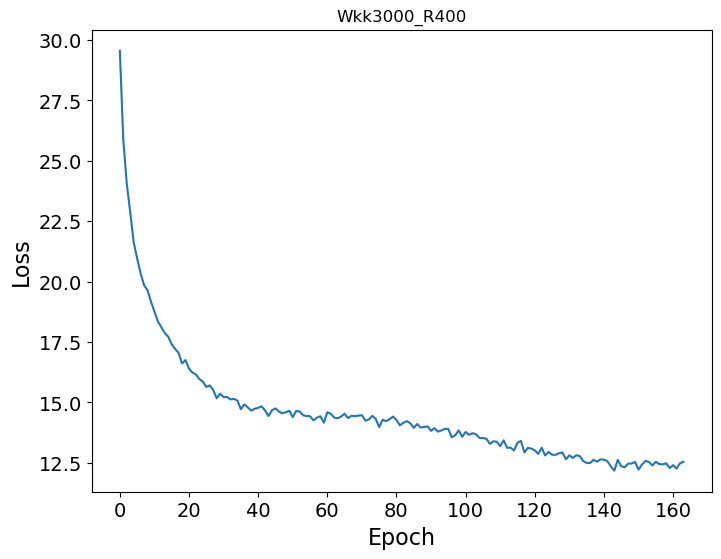

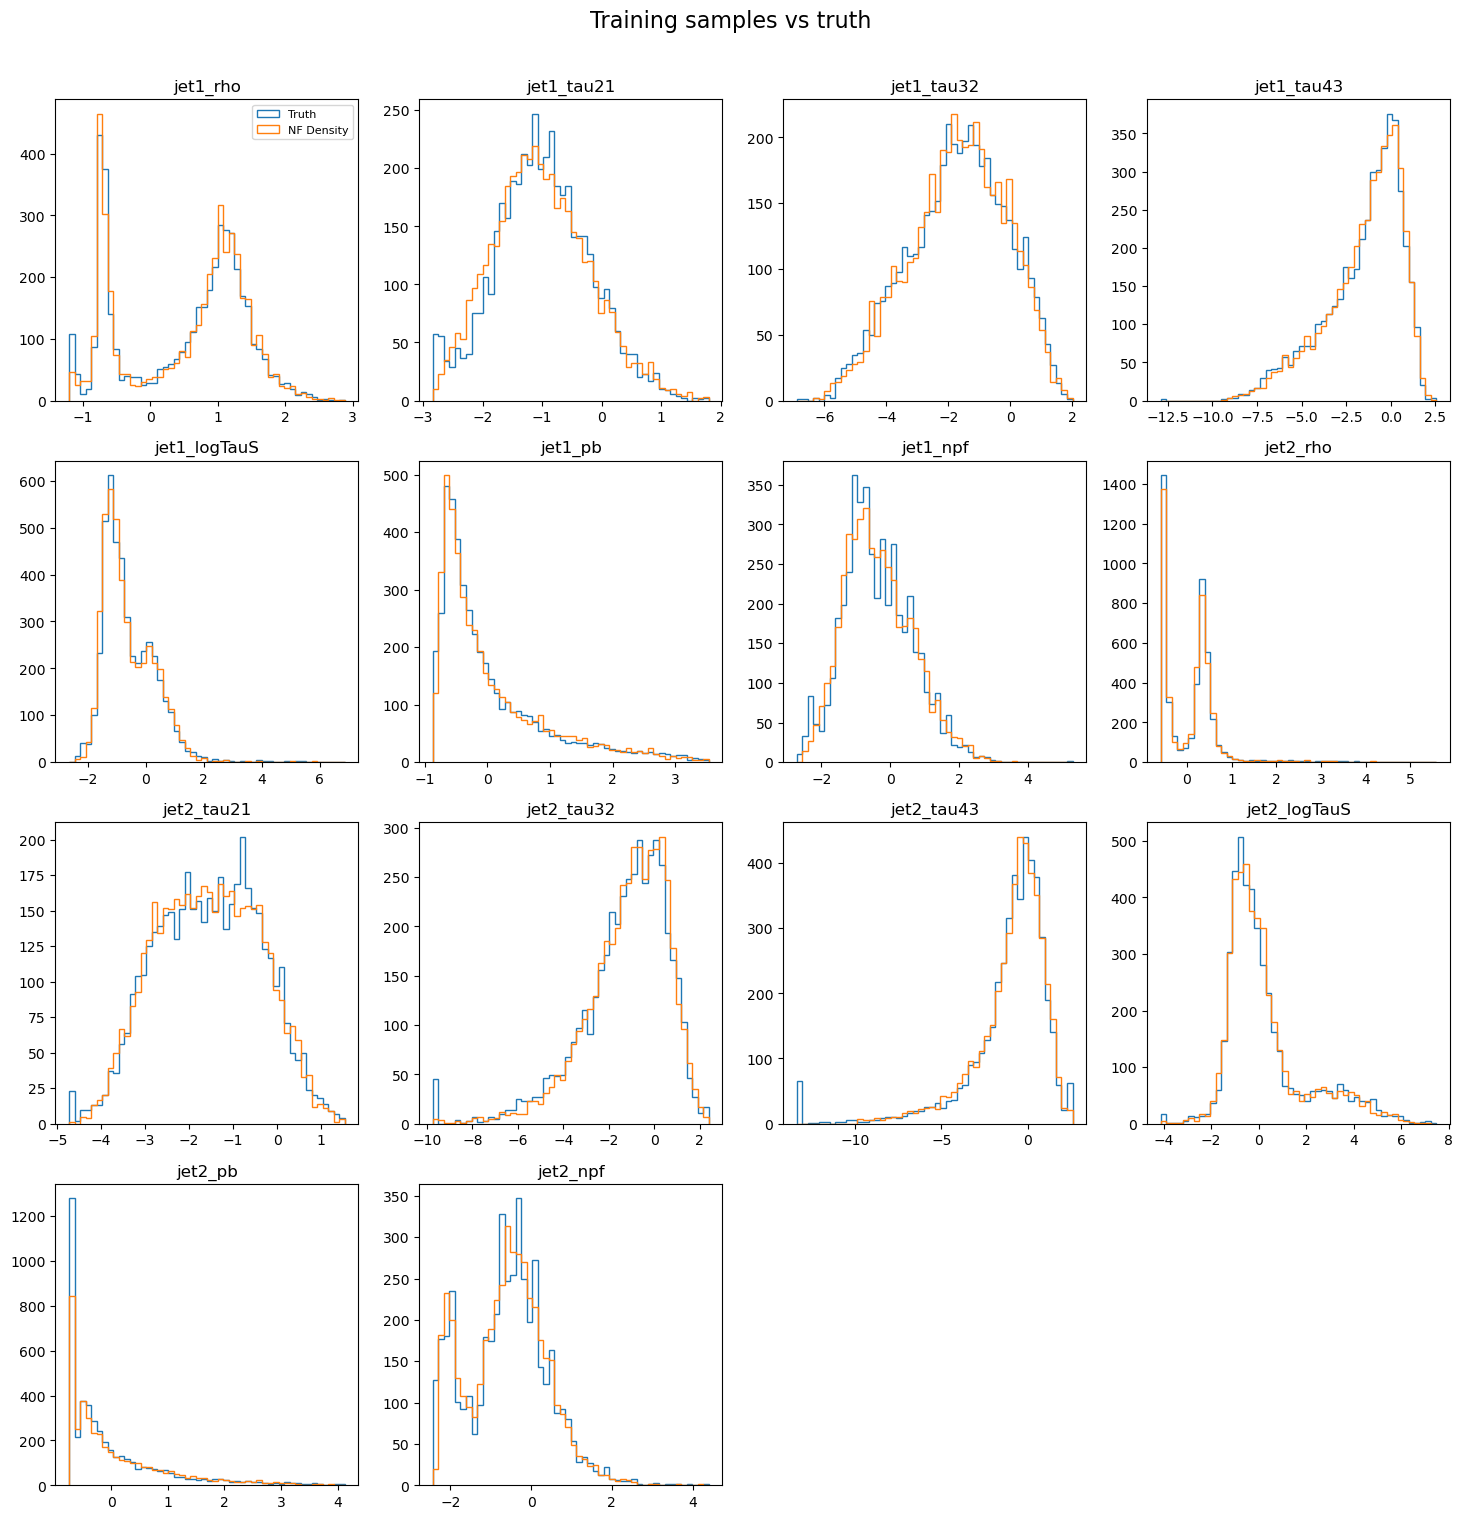

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 55.84it/s]


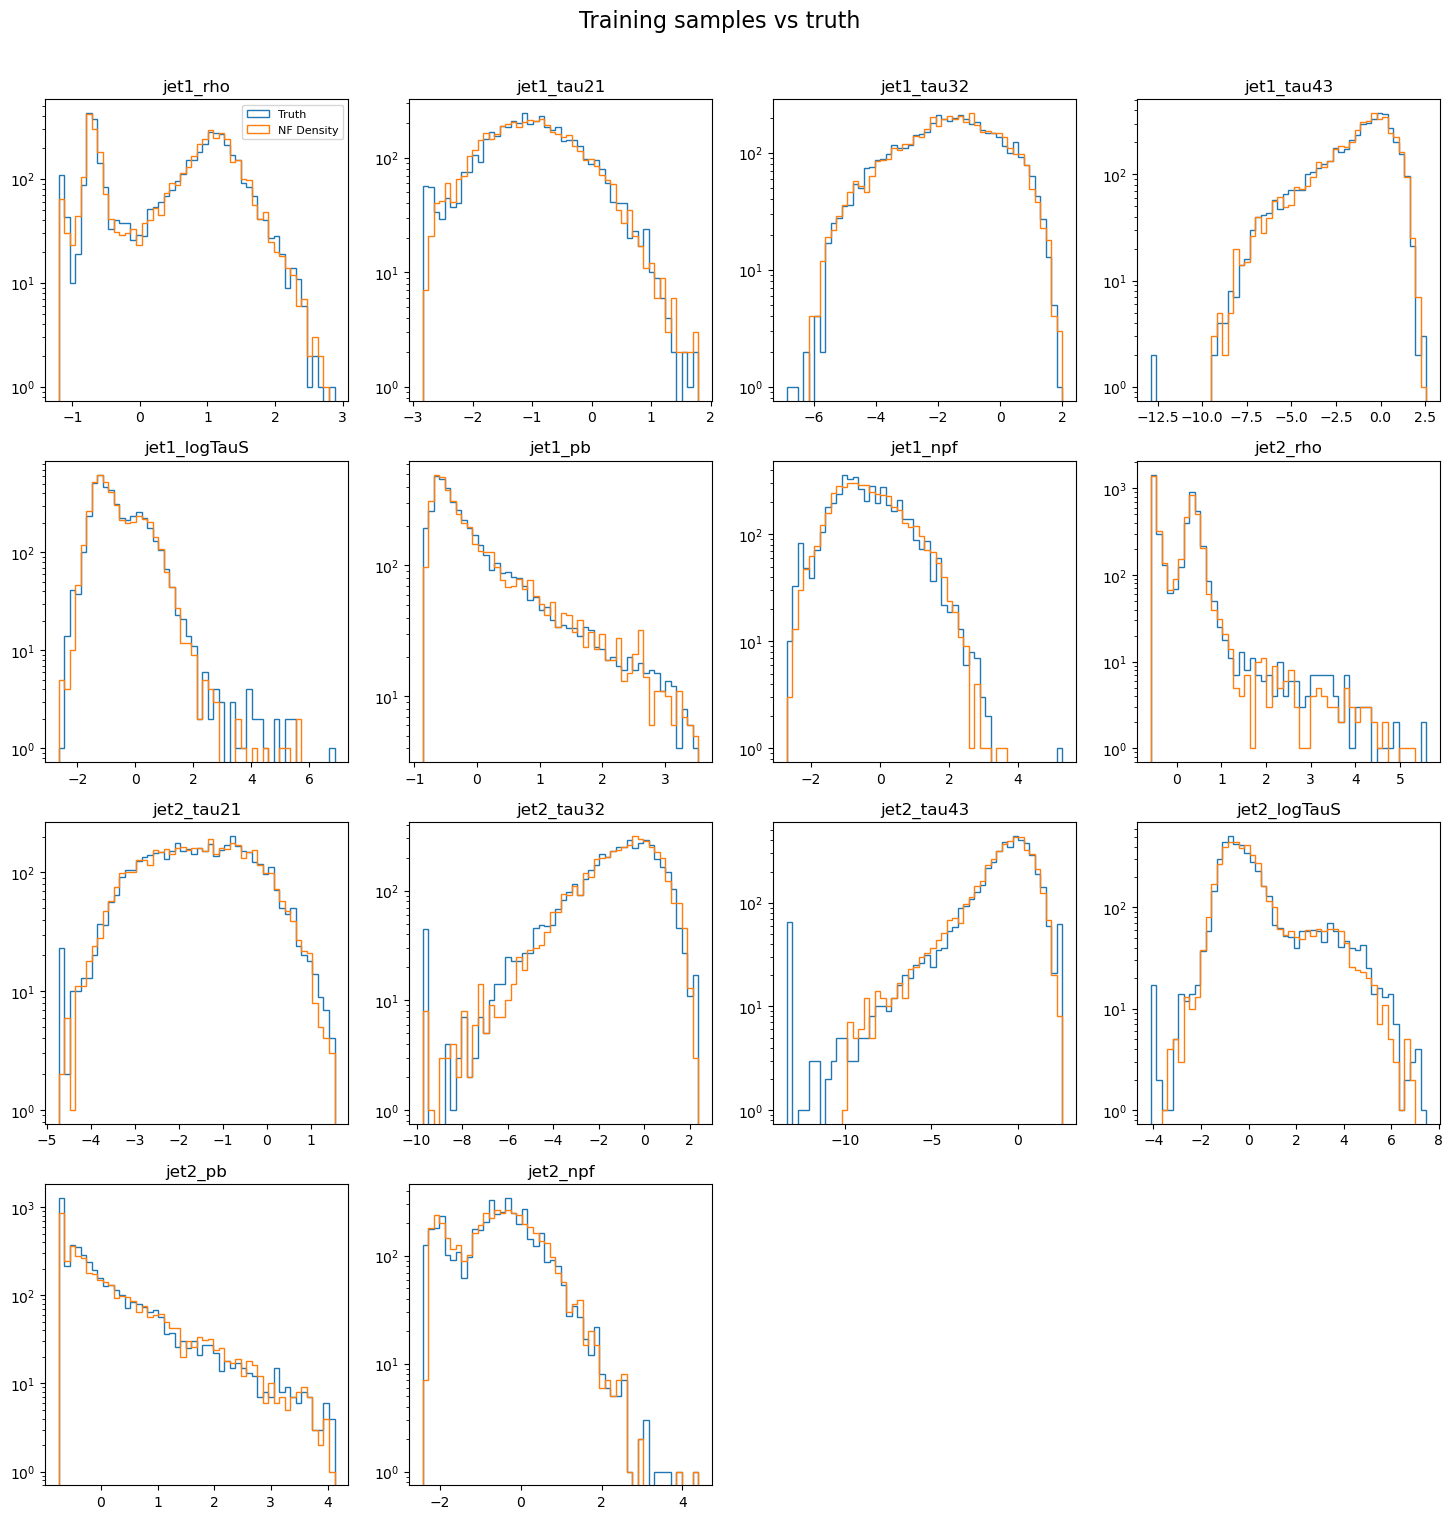

In [14]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":10,"hidden_features":200,"num_layers":6,
             "num_bins":100,"num_blocks_per_layer":5,"tails":"linear"}
sample = "Wkk3000_R400"
reference = "BKG"
variables = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
nTrain = 1000000
trainer = NFTrainer(sample,reference,variables,nTrain=nTrain,NF_kwargs=NF_kwargs)
trainer.train(bs=3000,n_epoch=200,patience=20,learning_rate=1e-4,T_max=50,eta_min=1e-5,print_interval=10)
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 55.30it/s]


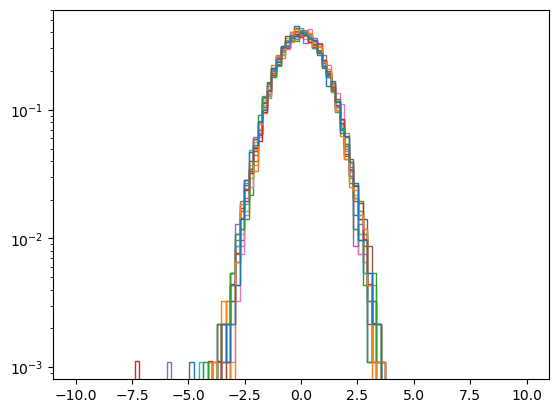

In [15]:
test = trainer.get_model().to(device)
data = trainer.loadData(10000,mode='test')
with torch.no_grad():
    samples = test.transform_to_noise(torch.tensor(data,dtype=torch.float32)).detach().cpu().numpy()
h = plt.hist(samples,histtype='step',density=True,bins=np.linspace(-10,10,100))
del test, data, samples
torch.cuda.empty_cache()
plt.yscale('log')

# RSG3000

Loading train sample


100%|██████████| 1/1 [00:00<00:00,  3.74it/s]


40347 training events
Training flow RSG3000
Iteration 10 Complete
Loss:  16.096906661987305
Iteration 20 Complete
Loss:  14.91573429107666
Iteration 30 Complete
Loss:  14.402971267700195
Iteration 40 Complete
Loss:  14.15640640258789
Iteration 50 Complete
Loss:  14.105507850646973
Iteration 60 Complete
Loss:  14.069539070129395
Iteration 70 Complete
Loss:  13.977119445800781
Iteration 80 Complete
Loss:  13.95352840423584
Iteration 90 Complete
Loss:  13.720081329345703
Iteration 100 Complete
Loss:  13.610614776611328
Iteration 110 Complete
Loss:  13.53719425201416
Iteration 120 Complete
Loss:  13.44558334350586
Iteration 130 Complete
Loss:  13.358536720275879
Iteration 140 Complete
Loss:  13.280006408691406
Iteration 150 Complete
Loss:  13.282830238342285
Iteration 160 Complete
Loss:  13.29409122467041
Iteration 170 Complete
Loss:  13.307738304138184
Loading test sample


100%|██████████| 1/1 [00:00<00:00,  3.08it/s]


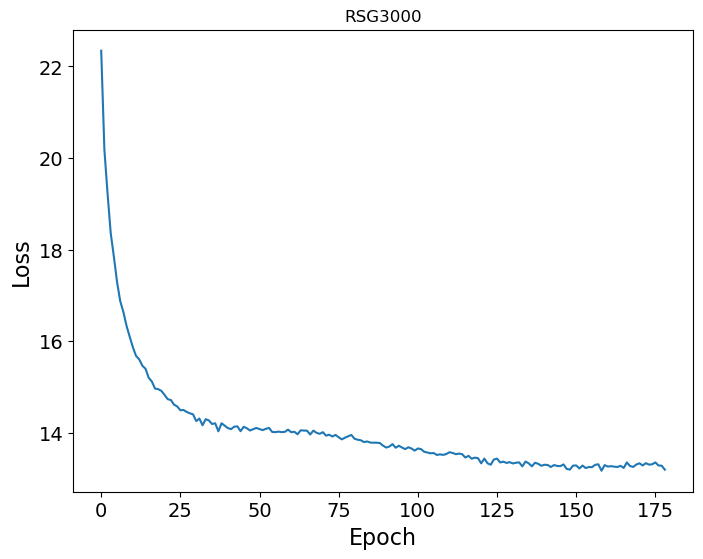

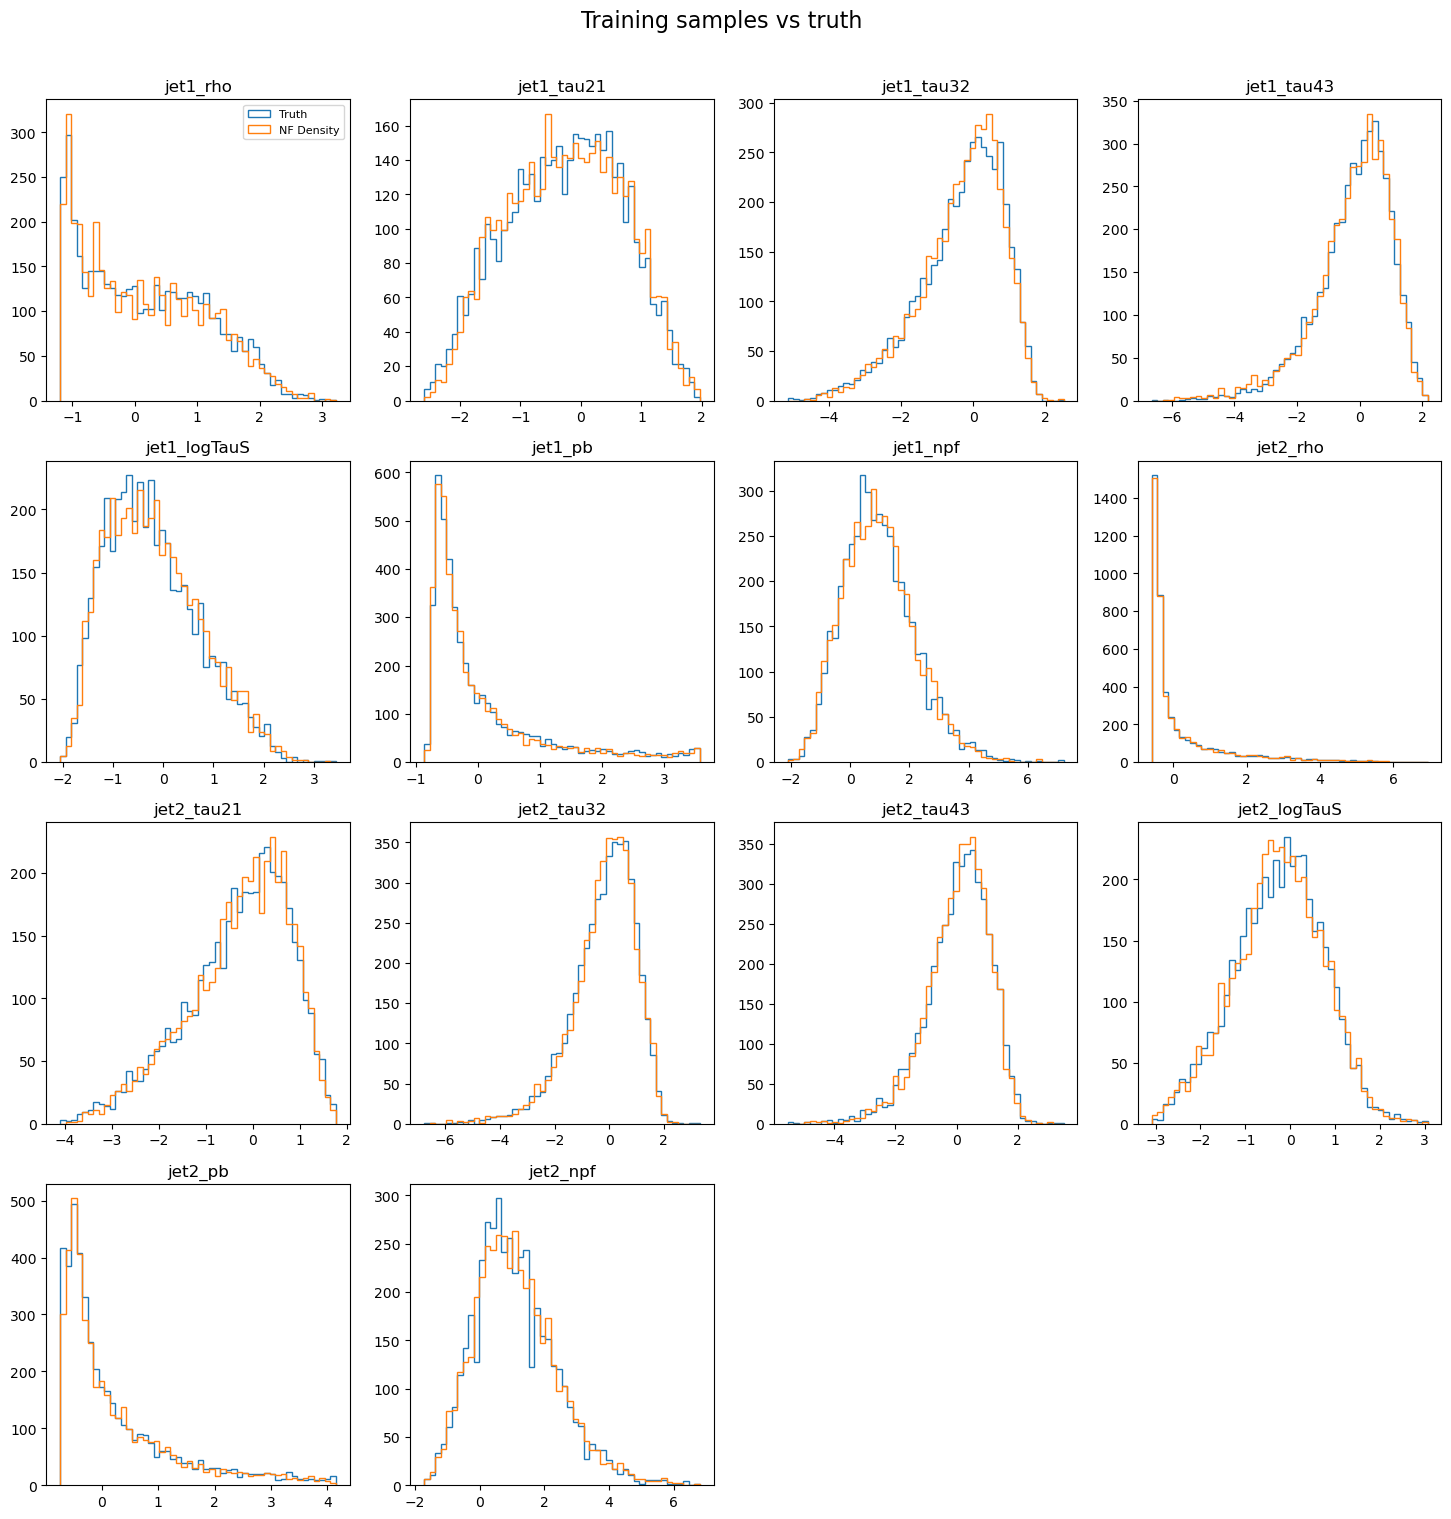

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 50.84it/s]


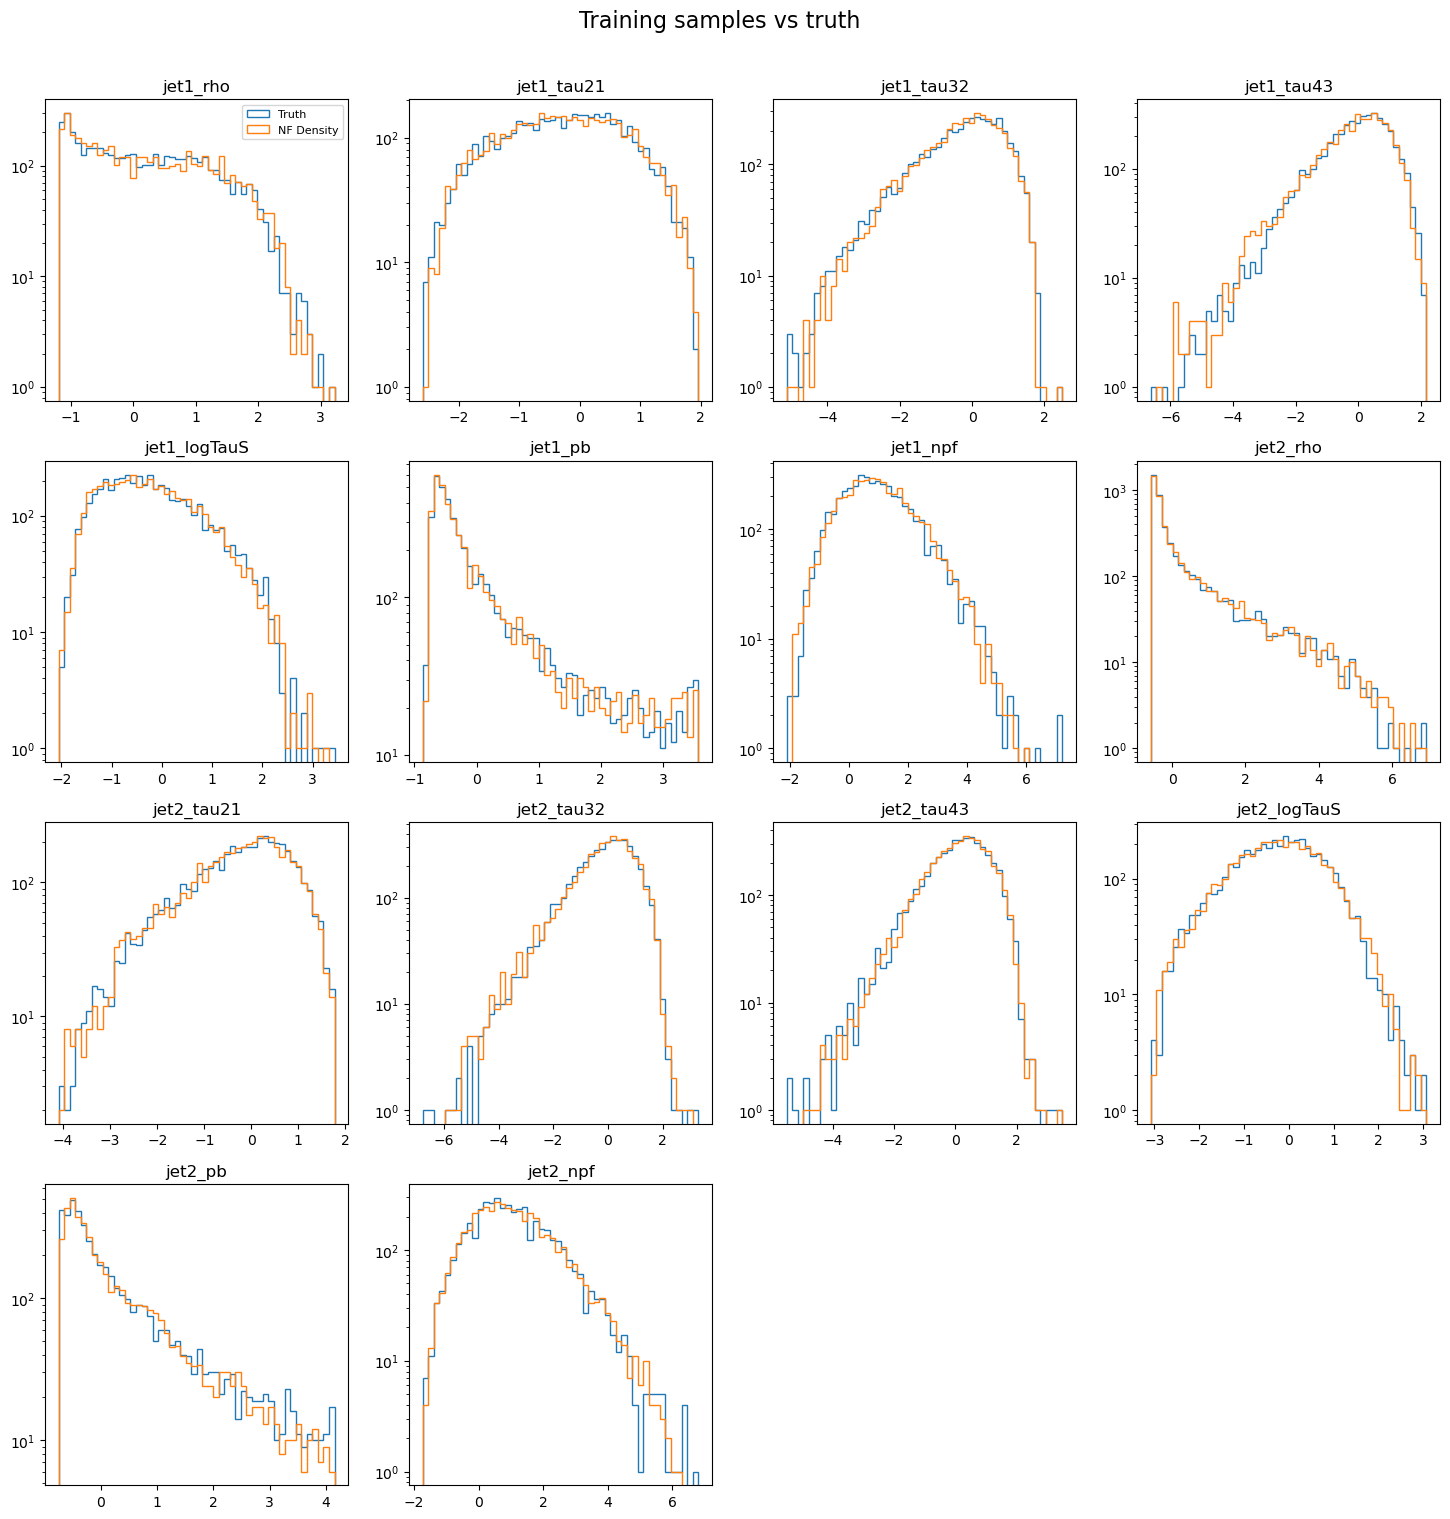

In [16]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":10,"hidden_features":160,"num_layers":4,
             "num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}
sample = "RSG3000"
reference = "BKG"
variables = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
nTrain = 1000000
trainer = NFTrainer(sample,reference,variables,nTrain=nTrain,NF_kwargs=NF_kwargs)
trainer.train(bs=3000,n_epoch=200,patience=20,learning_rate=1e-4,T_max=50,eta_min=1e-5,print_interval=10)
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)

Loading test sample


100%|██████████| 1/1 [00:00<00:00,  3.51it/s]


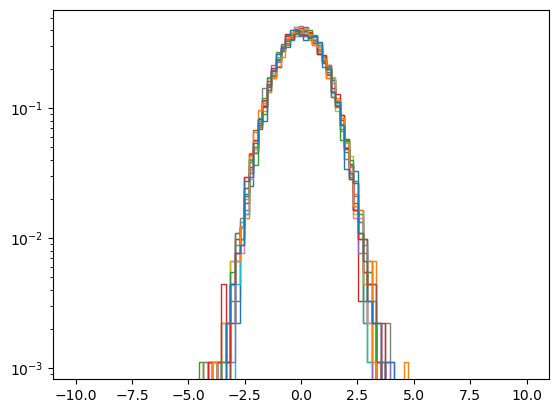

In [17]:
test = trainer.get_model().to(device)
data = trainer.loadData(10000,mode='test')
with torch.no_grad():
    samples = test.transform_to_noise(torch.tensor(data,dtype=torch.float32)).detach().cpu().numpy()
h = plt.hist(samples,histtype='step',density=True,bins=np.linspace(-10,10,100))
del test, data, samples
torch.cuda.empty_cache()
plt.yscale('log')

# 2017 Mixed Samples

114418 training events
Training flow XYY_X3000_Y80_UL17-and-Wp3000_B400_UL17-and-Qstar2000_W400_UL17
Iteration 10 Complete
Loss:  15.012701034545898
Iteration 20 Complete
Loss:  14.50737476348877
Iteration 30 Complete
Loss:  14.220305442810059
Iteration 40 Complete
Loss:  14.075905799865723
Iteration 50 Complete
Loss:  13.923693656921387
Iteration 60 Complete
Loss:  13.871459007263184
Iteration 70 Complete
Loss:  13.696602821350098
Iteration 80 Complete
Loss:  13.636523246765137
Iteration 90 Complete
Loss:  13.483439445495605
Iteration 100 Complete
Loss:  13.453718185424805
Iteration 110 Complete
Loss:  13.306290626525879
Iteration 120 Complete
Loss:  13.313313484191895
Iteration 130 Complete
Loss:  13.214077949523926
Iteration 140 Complete
Loss:  13.15955638885498
Iteration 150 Complete
Loss:  13.019516944885254
Iteration 160 Complete
Loss:  13.062255859375
Iteration 170 Complete
Loss:  12.981705665588379
Iteration 180 Complete
Loss:  12.920781135559082
Iteration 190 Complete
Loss:  1

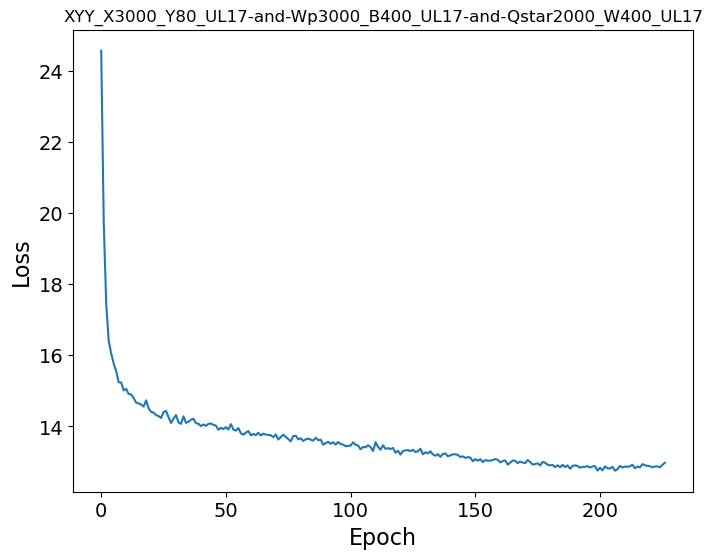

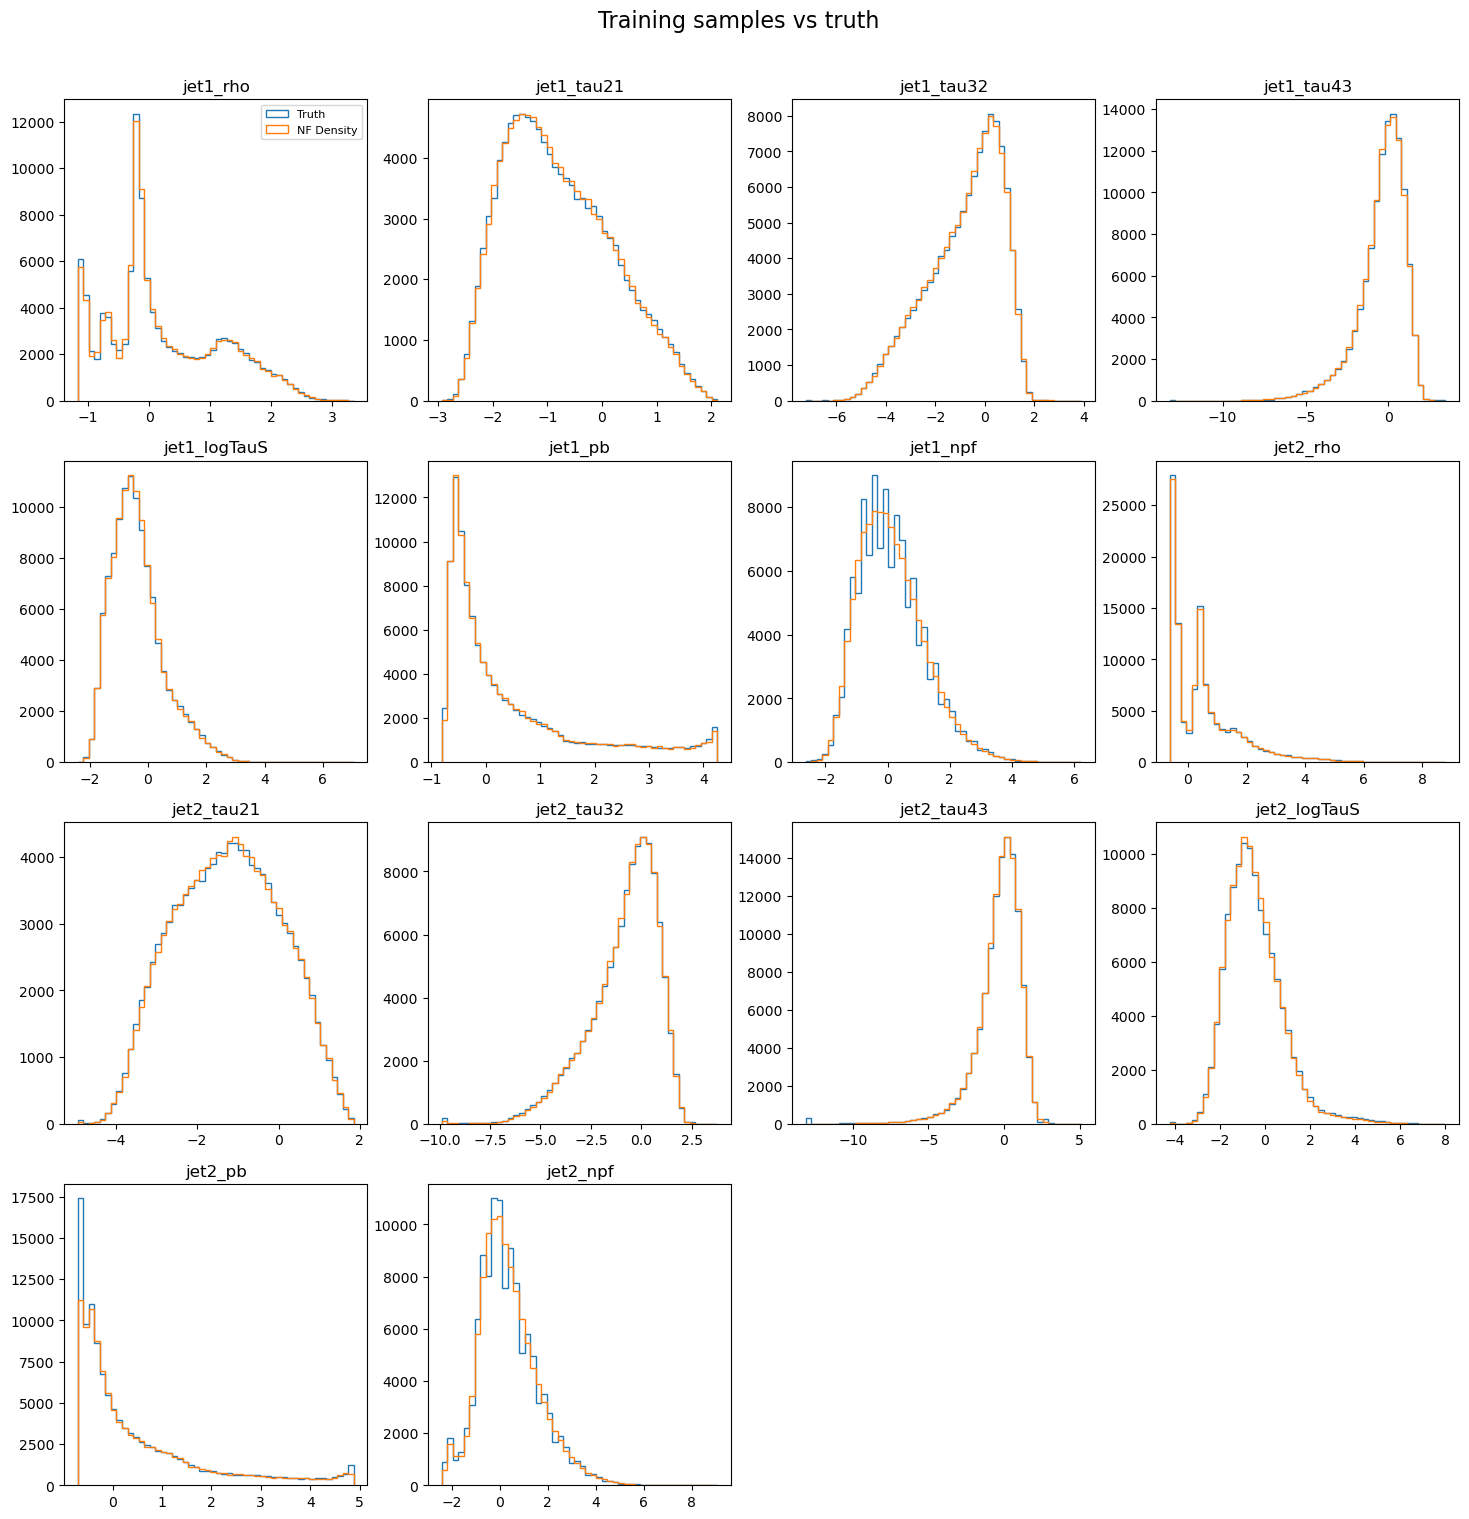

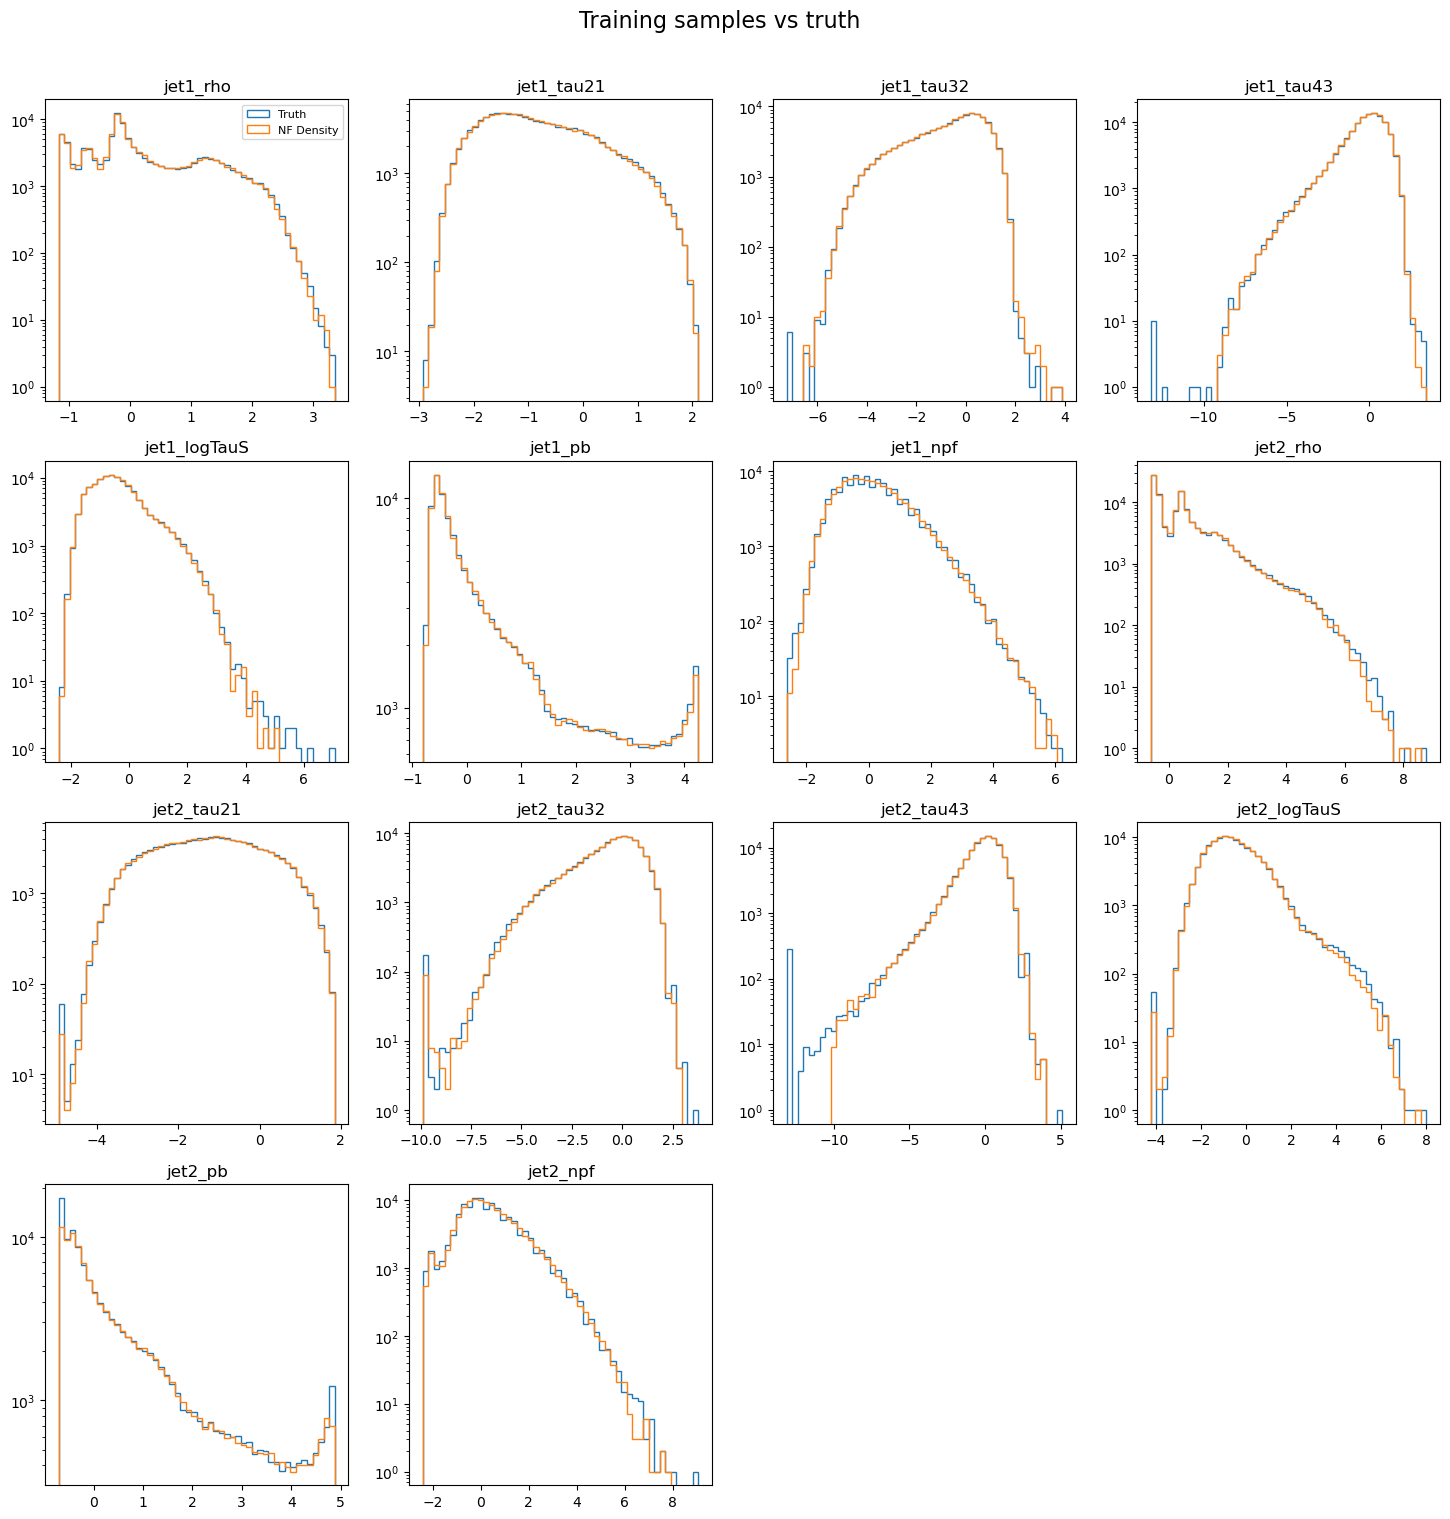

In [2]:
# XYY_X3000_Y80_UL17 + Wp3000_B400_UL17 + Qstar2000_W400_UL17
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":10,"hidden_features":250,
             "num_layers":6,"num_bins":40,"num_blocks_per_layer":4}
sample = ["XYY_X3000_Y80_UL17","Wp3000_B400_UL17","Qstar2000_W400_UL17"]
reference = "QCDBKG"
year = 2017
variables = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
nTrain = 1000000
trainer = NFTrainer(sample,reference,year,variables,nTrain=nTrain,NF_kwargs=NF_kwargs)
trainer.train(bs=10000,n_epoch=400,patience=20,learning_rate=1e-3,eta_min=1e-5,print_interval=10,clip=15)
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)